**Script to check basic features of UKESM G6solar precip field.**

Few things to check first:

Plotting global mean surface temperature (GMST). Meaning, if the Global mean surface temperature between G6 and SSP245 is 0, then it would mean that G6 has successfully cooled the world from SSP585 to SSP245.

Also, need to plot G6solar and G6sulfur to see if it is OK to use G6solar. Maybe plot the zonal mean cross-section also.

In [2]:
import xarray as xr
from pathlib import Path
import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# =========================
# User-defined metadata
# =========================

varname = "pr"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

In [4]:
#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


In [5]:
#Experiment details
EXPERIMENTS = {
    "HIST":     {"project": "CMIP",        "scenario": "historical", "color": "black"},
    "SSP245":   {"project": "ScenarioMIP", "scenario": "ssp245", "color": "blue"},
    "SSP585":   {"project": "ScenarioMIP", "scenario": "ssp585", "color": "orange"},
    "G6solar":  {"project": "GeoMIP",      "scenario": "G6solar", "color": "green"},
    "G6sulfur": {"project": "GeoMIP",      "scenario": "G6sulfur", "color": "red"},
}

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

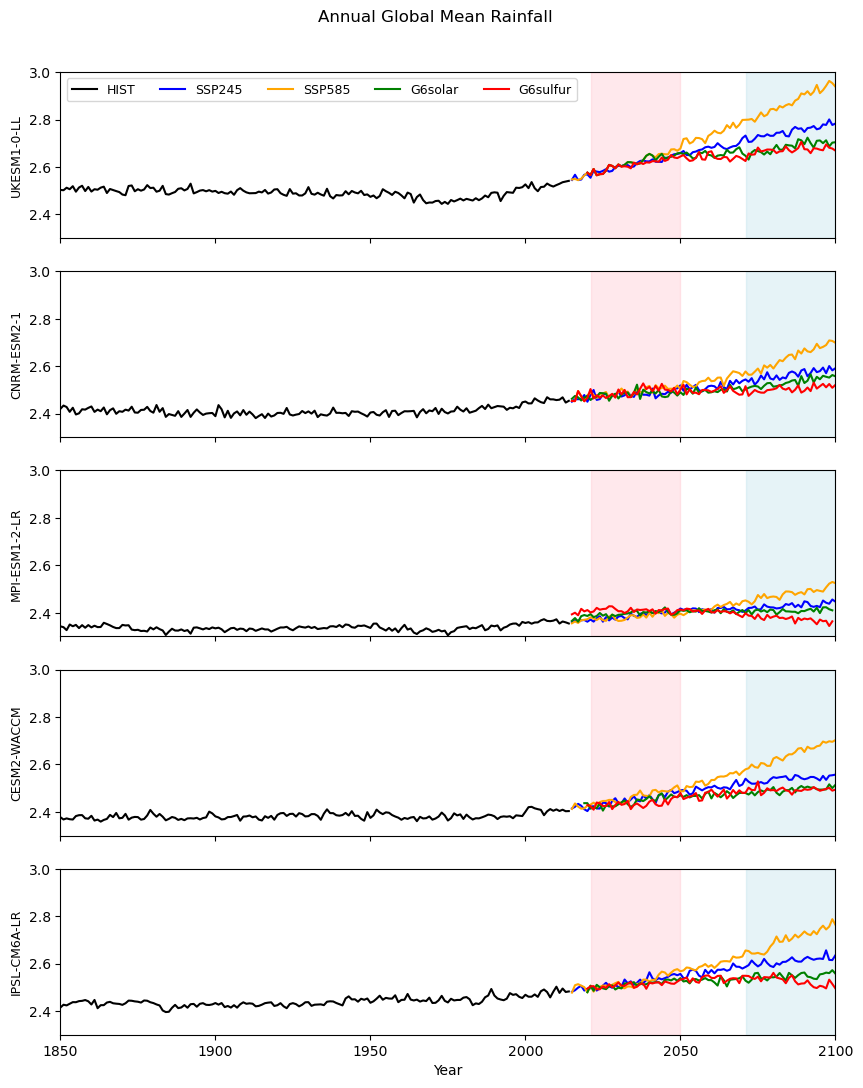

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(MODELS),
    ncols=1,
    figsize=(10, 2.5 * len(MODELS)),
    sharex=True,
)

axes = np.atleast_1d(axes)

for ax, (model_name, model_meta) in zip(axes, MODELS.items()):

    var = {}
    var_by_year = {}

    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():

        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]


        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )

        print(str(base))
        # ds = mf.open_files(str(base))
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))

        var[exp] = mf.read_var(ds, varname)

    # --- seasonal means (KEEP seasons dict as-is) ---
    seasons = {
        "ANN":  (1, 12),
        # "JJAS": (6, 9),
        # "DJF":  (12, 2),
    }

    for exp, da in var.items():
        var_by_year[exp] = {}
        for season, (m1, m2) in seasons.items():
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da, m1, m2)

    # --- plotting (ANN only for now) ---
    for exp, meta in EXPERIMENTS.items():
        ts = var_by_year[exp]["ANN"].mean(dim=("lat", "lon"))*86400
        ax.plot(
            ts.year,
            ts,
            label=exp,
            color=meta.get("color", None),
        )

    ax.set_ylabel(model_name, fontsize=9)
    ax.set_ylim(2.3,3)
    # ax.grid(True)
    # ax.axhline(y=277, color='gray', linestyle='--')
    ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
    ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)

axes[-1].set_xlabel("Year")
axes[0].legend(ncol=5, fontsize=9, loc="upper left")

plt.suptitle("Annual Global Mean Rainfall", y=0.93)
plt.xlim(1850, 2100)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_GlobalMeanRainfall_AllModels_PI2PD2SAI"
# # plt.savefig(''+str(fig_directory)+'/'+str(figname)+'.svg', format="svg",transparent=True, dpi=1200)
# # !rsvg-convert -f pdf -o {fig_directory}/{figname}.pdf {fig_directory}/{figname}.svg
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf")

plt.show()


/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

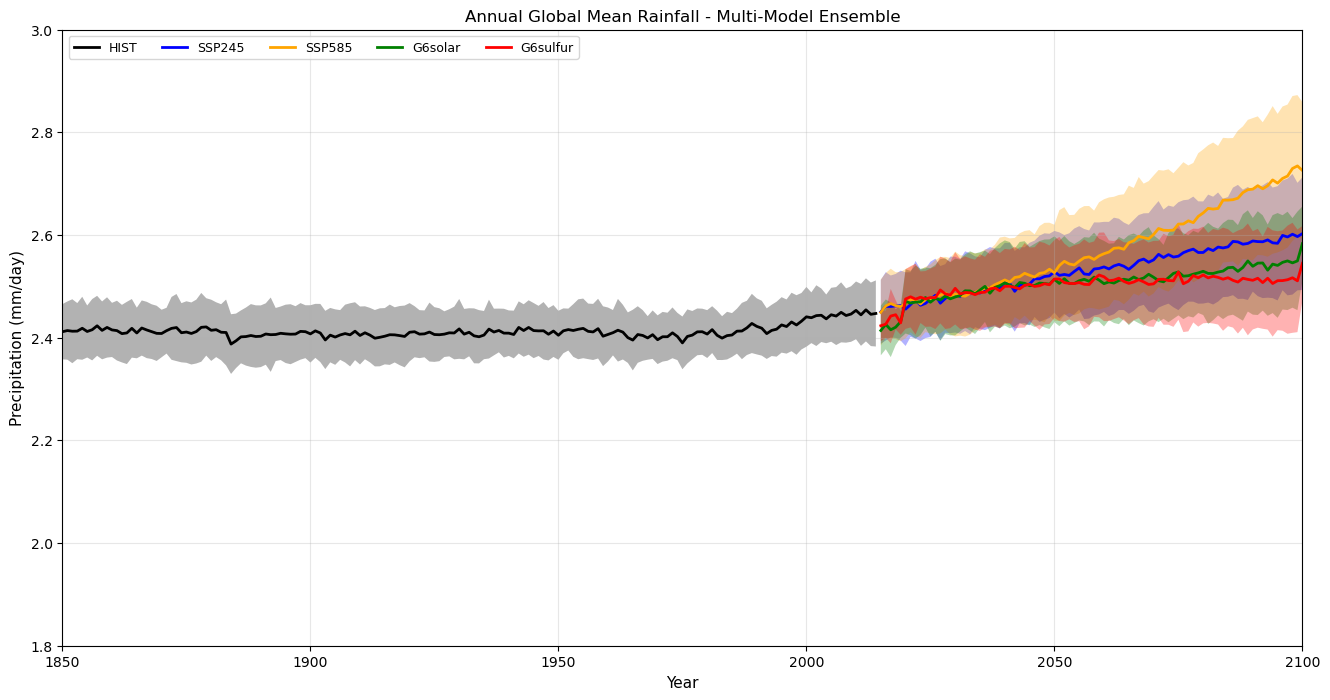

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
    
    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        for season, (m1, m2) in seasons.items():
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da, m1, m2)
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"].mean(dim=("lat", "lon")) * 86400
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
ensemble_means = {}
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    

    # Save ensemble_mean
    ensemble_means[exp] = ensemble_mean
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,  # Use facecolor instead of color
        alpha=0.3,
        edgecolor='none',  # Remove edge color
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(1.8, 3.0)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual Global Mean Rainfall - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_GlobalMeanRainfall_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [30]:
P_ens=ensemble_means
%store P_ens

Stored 'P_ens' (dict)


/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

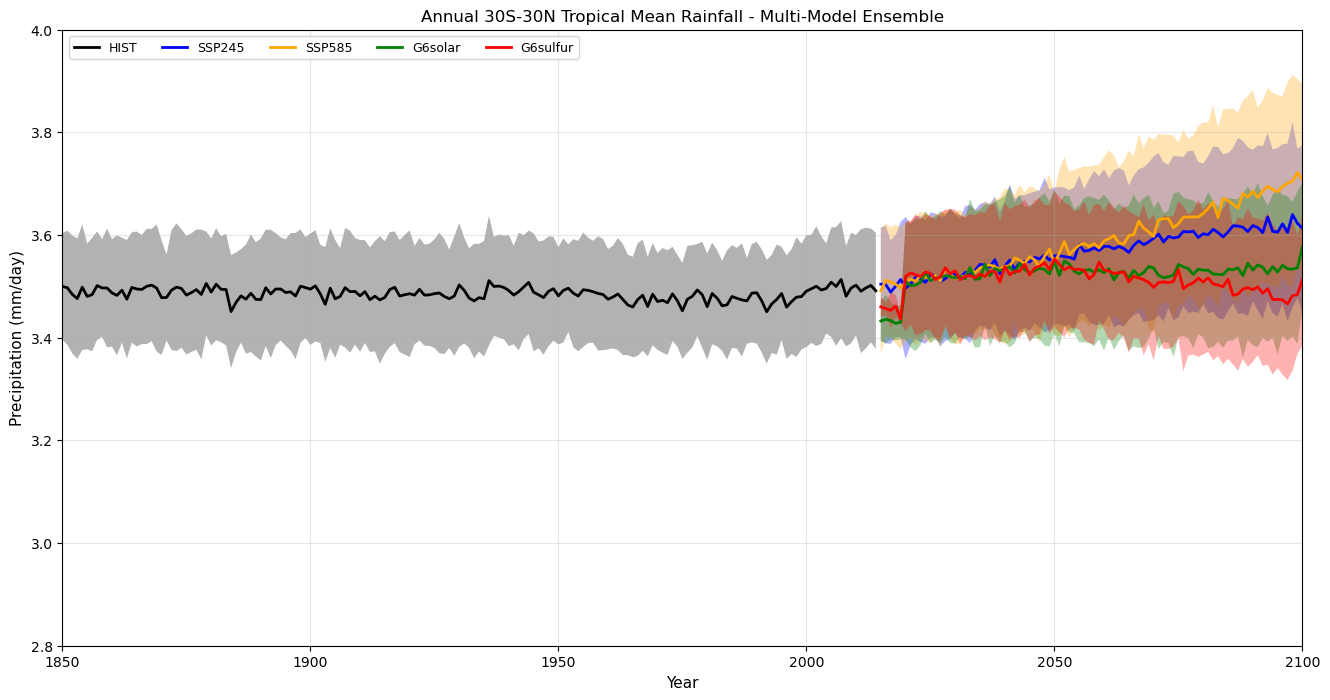

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude=30
        var[exp] = var[exp].sel(lat=slice(-tropics_latitude, tropics_latitude))
    
    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        for season, (m1, m2) in seasons.items():
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da, m1, m2)
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"].mean(dim=("lat", "lon")) * 86400
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,  # Use facecolor instead of color
        alpha=0.3,
        edgecolor='none',  # Remove edge color
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(2.8, 4.0)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual 30S-30N Tropical Mean Rainfall - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_TropicalMeanRainfall_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

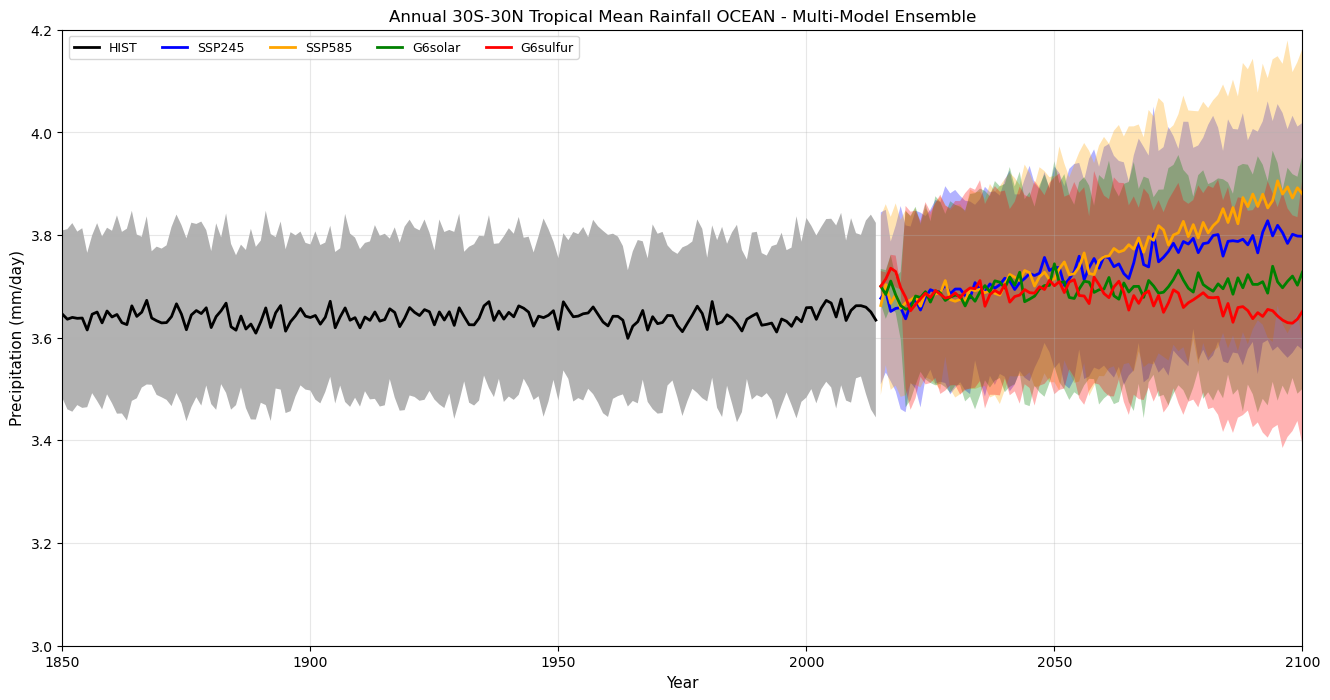

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude = 30
        var[exp] = var[exp].sel(lat=slice(-tropics_latitude, tropics_latitude))

    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        
        # Create land/ocean mask ONCE per experiment (before seasonal processing)
        lat = da.lat.values
        lon = da.lon.values
        
        try:
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            # Create 2D lon/lat mesh for masking
            lon_2d, lat_2d = np.meshgrid(lon, lat)
            mask_2d = land_110.mask(lon_2d, lat_2d)
            
            # Create land mask DataArray (True where land exists)
            land_mask_da = xr.DataArray(
                ~np.isnan(mask_2d.values),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        except (ImportError, AttributeError) as e:
            import warnings
            warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
            land_mask_da = xr.DataArray(
                np.ones((len(lat), len(lon)), dtype=bool),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        
        ocean_mask_da = ~land_mask_da
        
        # Apply mask to the full DataArray BEFORE seasonal processing
        # da_land = da.where(land_mask_da)  # LAND
        da_ocean = da.where(ocean_mask_da)  # OCEAN (use this instead for ocean)
        
        # Now calculate seasonal means on the masked data
        for season, (m1, m2) in seasons.items():
            # var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da_ocean, m1, m2).mean(dim=("lat", "lon"))  # For ocean
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"] * 86400  # REMOVED the extra .mean(dim=("lat", "lon"))
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,
        alpha=0.3,
        edgecolor='none',
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(3.0, 4.2)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual 30S-30N Tropical Mean Rainfall OCEAN - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_TropicalMeanRainfall_OCEAN_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

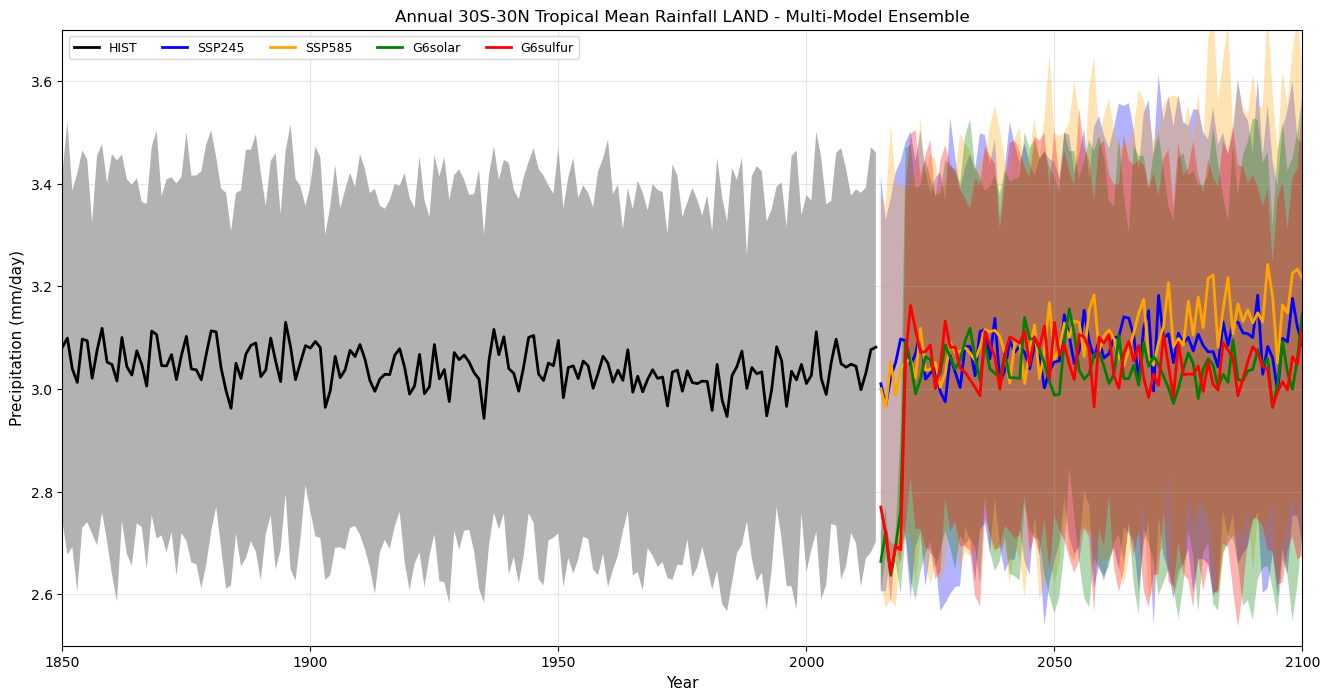

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude = 30
        var[exp] = var[exp].sel(lat=slice(-tropics_latitude, tropics_latitude))

    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        
        # Create land/ocean mask ONCE per experiment (before seasonal processing)
        lat = da.lat.values
        lon = da.lon.values
        
        try:
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            # Create 2D lon/lat mesh for masking
            lon_2d, lat_2d = np.meshgrid(lon, lat)
            mask_2d = land_110.mask(lon_2d, lat_2d)
            
            # Create land mask DataArray (True where land exists)
            land_mask_da = xr.DataArray(
                ~np.isnan(mask_2d.values),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        except (ImportError, AttributeError) as e:
            import warnings
            warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
            land_mask_da = xr.DataArray(
                np.ones((len(lat), len(lon)), dtype=bool),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        
        ocean_mask_da = ~land_mask_da
        
        # Apply mask to the full DataArray BEFORE seasonal processing
        da_land = da.where(land_mask_da)  # LAND
        # da_ocean = da.where(ocean_mask_da)  # OCEAN (use this instead for ocean)
        
        # Now calculate seasonal means on the masked data
        for season, (m1, m2) in seasons.items():
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
            # var_by_year[exp][season] = mf.seasonal_mean_by_year(da_ocean, m1, m2).mean(dim=("lat", "lon"))  # For ocean
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"] * 86400  # REMOVED the extra .mean(dim=("lat", "lon"))
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,
        alpha=0.3,
        edgecolor='none',
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(2.5, 3.7)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual 30S-30N Tropical Mean Rainfall LAND - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_TropicalMeanRainfall_LAND_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

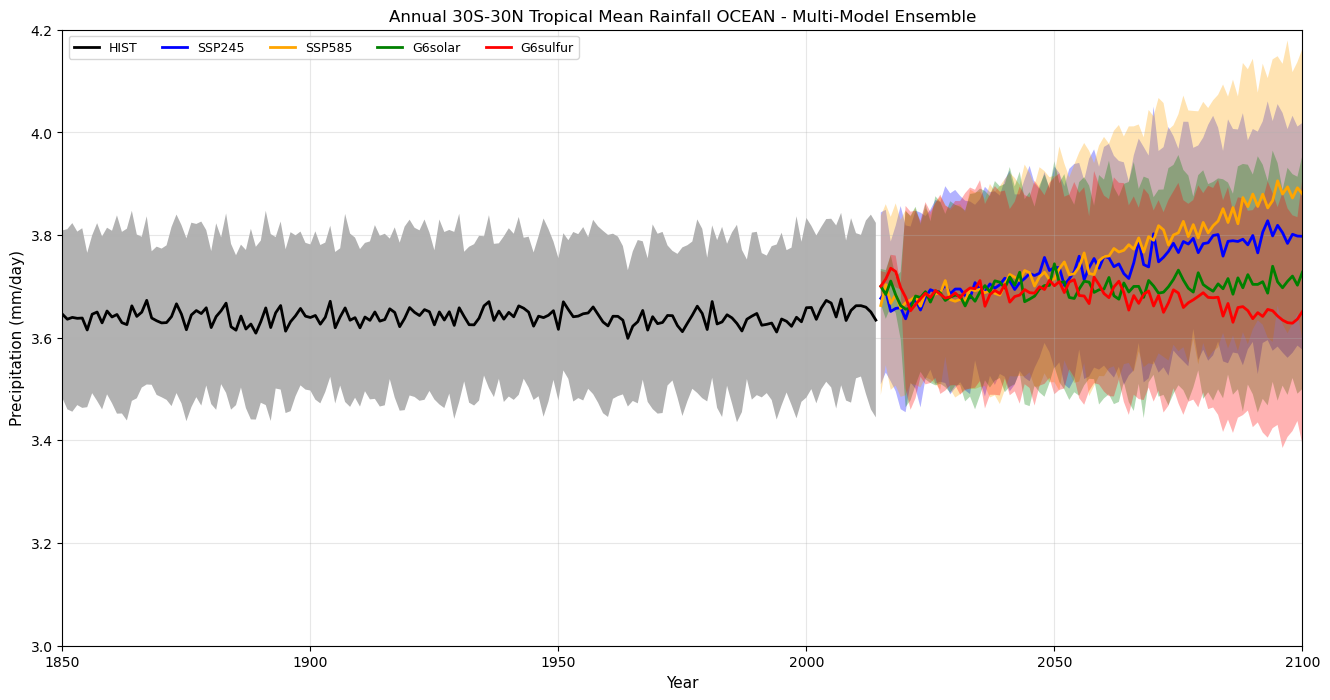

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude = 30
        var[exp] = var[exp].sel(lat=slice(-tropics_latitude, tropics_latitude))

    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        
        # Create land/ocean mask ONCE per experiment (before seasonal processing)
        lat = da.lat.values
        lon = da.lon.values
        
        try:
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            # Create 2D lon/lat mesh for masking
            lon_2d, lat_2d = np.meshgrid(lon, lat)
            mask_2d = land_110.mask(lon_2d, lat_2d)
            
            # Create land mask DataArray (True where land exists)
            land_mask_da = xr.DataArray(
                ~np.isnan(mask_2d.values),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        except (ImportError, AttributeError) as e:
            import warnings
            warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
            land_mask_da = xr.DataArray(
                np.ones((len(lat), len(lon)), dtype=bool),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        
        ocean_mask_da = ~land_mask_da
        
        # Apply mask to the full DataArray BEFORE seasonal processing
        # da_land = da.where(land_mask_da)  # LAND
        da_ocean = da.where(ocean_mask_da)  # OCEAN (use this instead for ocean)
        
        # Now calculate seasonal means on the masked data
        for season, (m1, m2) in seasons.items():
            # var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da_ocean, m1, m2).mean(dim=("lat", "lon"))  # For ocean
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"] * 86400  # REMOVED the extra .mean(dim=("lat", "lon"))
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,
        alpha=0.3,
        edgecolor='none',
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(3, 4.2)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual 30S-30N Tropical Mean Rainfall OCEAN - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_TropicalMeanRainfall_OCEAN_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7f46f72591c0>
Traceback (most recent call last):
  File "/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

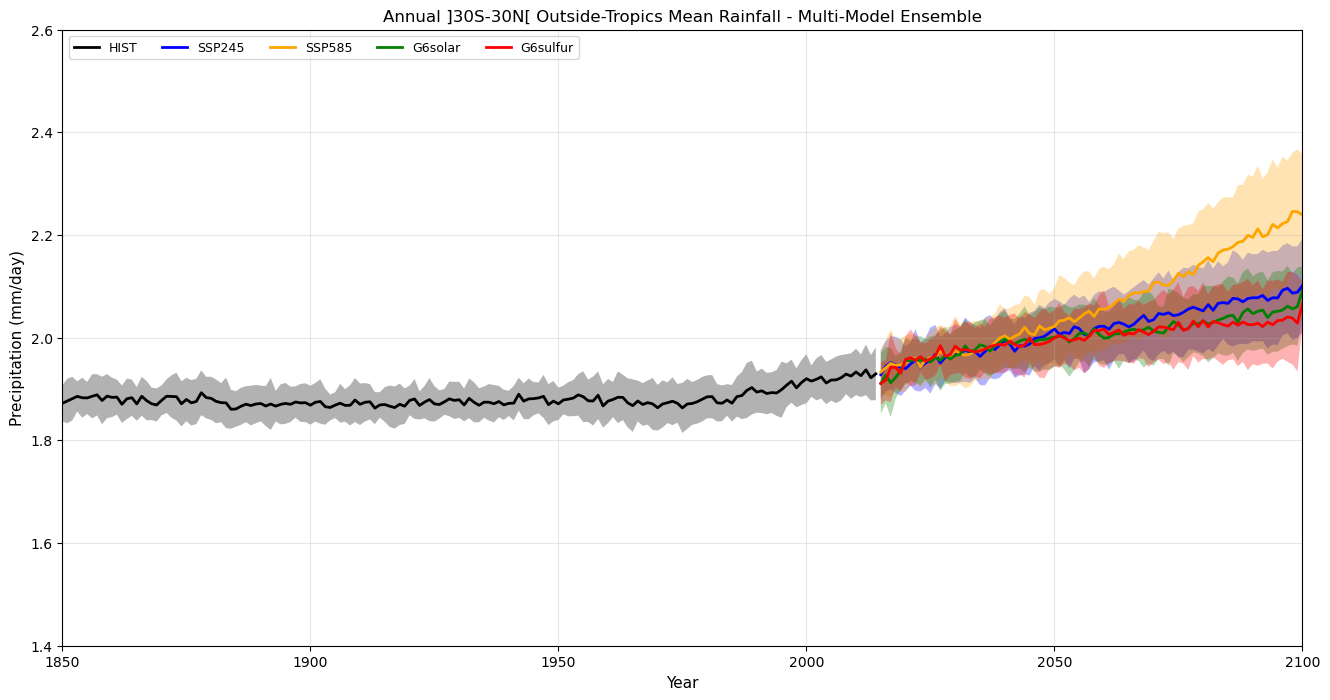

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude = 30
        # Select extratropics: south of 30S OR north of 30N
        var_south = var[exp].sel(lat=slice(-90, -tropics_latitude))  # 90S to 30S
        var_north = var[exp].sel(lat=slice(tropics_latitude, 90))    # 30N to 90N

        # Combine both hemispheres
        var[exp] = xr.concat([var_south, var_north], dim='lat')

    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        for season, (m1, m2) in seasons.items():
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da, m1, m2)
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"].mean(dim=("lat", "lon")) * 86400
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,
        alpha=0.3,
        edgecolor='none',
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(1.4, 2.6)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual ]30S-30N[ Outside-Tropics Mean Rainfall - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_ExtraTropicalMeanRainfall_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

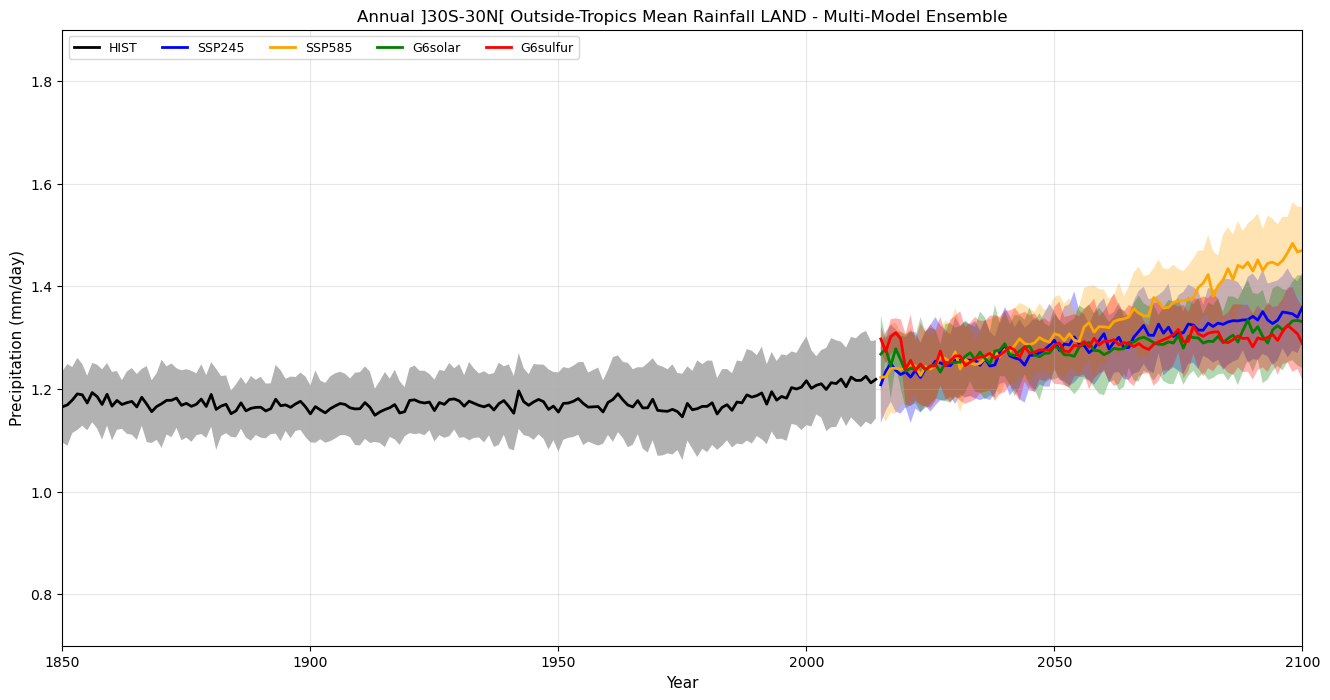

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude = 30
        # Select extratropics: south of 30S OR north of 30N
        var_south = var[exp].sel(lat=slice(-90, -tropics_latitude))  # 90S to 30S
        var_north = var[exp].sel(lat=slice(tropics_latitude, 90))    # 30N to 90N

        # Combine both hemispheres
        var[exp] = xr.concat([var_south, var_north], dim='lat')

    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        
        # Create land/ocean mask ONCE per experiment (before seasonal processing)
        lat = da.lat.values
        lon = da.lon.values
        
        try:
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            # Create 2D lon/lat mesh for masking
            lon_2d, lat_2d = np.meshgrid(lon, lat)
            mask_2d = land_110.mask(lon_2d, lat_2d)
            
            # Create land mask DataArray (True where land exists)
            land_mask_da = xr.DataArray(
                ~np.isnan(mask_2d.values),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        except (ImportError, AttributeError) as e:
            import warnings
            warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
            land_mask_da = xr.DataArray(
                np.ones((len(lat), len(lon)), dtype=bool),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        
        ocean_mask_da = ~land_mask_da
        
        # Apply mask to the full DataArray BEFORE seasonal processing
        da_land = da.where(land_mask_da)  # LAND
        # da_ocean = da.where(ocean_mask_da)  # OCEAN (use this instead for ocean)
        
        # Now calculate seasonal means on the masked data
        for season, (m1, m2) in seasons.items():
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
            # var_by_year[exp][season] = mf.seasonal_mean_by_year(da_ocean, m1, m2).mean(dim=("lat", "lon"))  # For ocean
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"] * 86400  # REMOVED the extra .mean(dim=("lat", "lon"))
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,
        alpha=0.3,
        edgecolor='none',
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(0.7, 1.9)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual ]30S-30N[ Outside-Tropics Mean Rainfall LAND - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_ExtraTropicalMeanRainfall_LAND_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/pr/gr/latest
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP

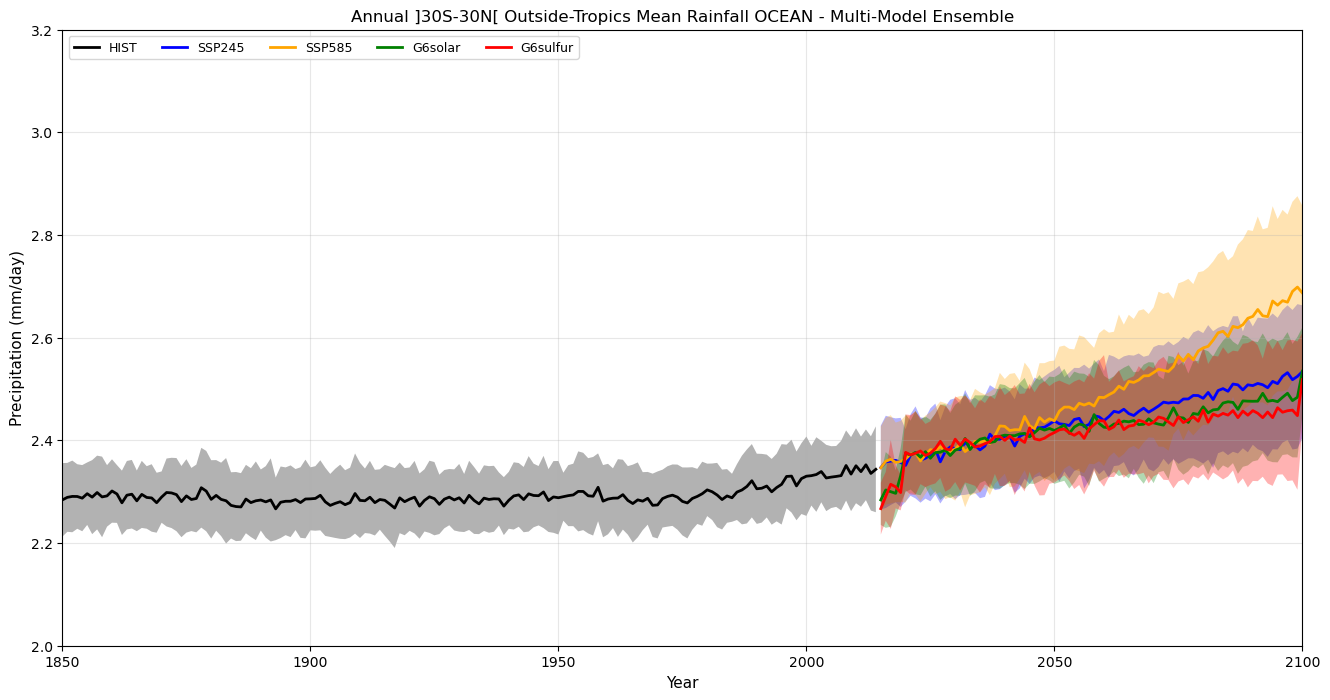

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

fig, ax = plt.subplots(figsize=(16, 8))

# Dictionary to store all model data by experiment
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}

# --- Collect data from all models ---
for model_name, model_meta in MODELS.items():
    var = {}
    var_by_year = {}
    
    # --- build paths + read data ---
    for exp, meta in EXPERIMENTS.items():
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))
        
        # Read data with model-specific handlers
        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ds = mf.open_files_CESM_G6sulfur(base)
            elif meta["scenario"] == "ssp585":
                ds = mf.open_files_CESM_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            if meta["scenario"] == "ssp585":
                ds = mf.open_files_IPSL_ssp585(base)
            else:
                ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))
        
        var[exp] = mf.read_var(ds, varname)
        tropics_latitude = 30
        # Select extratropics: south of 30S OR north of 30N
        var_south = var[exp].sel(lat=slice(-90, -tropics_latitude))  # 90S to 30S
        var_north = var[exp].sel(lat=slice(tropics_latitude, 90))    # 30N to 90N

        # Combine both hemispheres
        var[exp] = xr.concat([var_south, var_north], dim='lat')

    # --- seasonal means ---
    seasons = {
        "ANN": (1, 12),
    }
    
    for exp, da in var.items():
        var_by_year[exp] = {}
        
        # Create land/ocean mask ONCE per experiment (before seasonal processing)
        lat = da.lat.values
        lon = da.lon.values
        
        try:
            land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            # Create 2D lon/lat mesh for masking
            lon_2d, lat_2d = np.meshgrid(lon, lat)
            mask_2d = land_110.mask(lon_2d, lat_2d)
            
            # Create land mask DataArray (True where land exists)
            land_mask_da = xr.DataArray(
                ~np.isnan(mask_2d.values),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        except (ImportError, AttributeError) as e:
            import warnings
            warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
            land_mask_da = xr.DataArray(
                np.ones((len(lat), len(lon)), dtype=bool),
                dims=["lat", "lon"],
                coords={"lat": lat, "lon": lon}
            )
        
        ocean_mask_da = ~land_mask_da
        
        # Apply mask to the full DataArray BEFORE seasonal processing
        # da_land = da.where(land_mask_da)  # LAND
        da_ocean = da.where(ocean_mask_da)  # OCEAN (use this instead for ocean)
        
        # Now calculate seasonal means on the masked data
        for season, (m1, m2) in seasons.items():
            # var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
            var_by_year[exp][season] = mf.seasonal_mean_by_year(da_ocean, m1, m2).mean(dim=("lat", "lon"))  # For ocean
    
    # --- Store global mean time series for each experiment ---
    for exp in EXPERIMENTS.keys():
        ts = var_by_year[exp]["ANN"] * 86400  # REMOVED the extra .mean(dim=("lat", "lon"))
        data_by_experiment[exp].append(ts)

# --- Define common year range ---
common_years = np.arange(1850, 2101)  # Adjust as needed

# --- Plot ensemble mean and spread ---
for exp, meta in EXPERIMENTS.items():
    # Stack all model data for this experiment
    all_models = data_by_experiment[exp]
    
    if len(all_models) == 0:
        continue
    
    # Align all models to common year grid
    aligned_data = []
    for ts in all_models:
        # Create a pandas Series for easy reindexing
        series = pd.Series(ts.values, index=ts.year.values)
        # Reindex to common years (NaN where data doesn't exist)
        aligned = series.reindex(common_years)
        aligned_data.append(aligned.values)
    
    # Stack into 2D array (models x years)
    model_data = np.array(aligned_data)
    
    # Calculate ensemble mean and spread (ignoring NaNs)
    ensemble_mean = np.nanmean(model_data, axis=0)
    ensemble_std = np.nanstd(model_data, axis=0)
    
    # Only plot where we have at least one model's data
    valid_mask = ~np.isnan(ensemble_mean)
    
    # Plot mean line
    line_color = meta.get("color", None)
    ax.plot(
        common_years[valid_mask],
        ensemble_mean[valid_mask],
        label=exp,
        color=line_color,
        linewidth=2,
    )
    
    # Plot shaded spread (±1 standard deviation)
    ax.fill_between(
        common_years[valid_mask],
        (ensemble_mean - ensemble_std)[valid_mask],
        (ensemble_mean + ensemble_std)[valid_mask],
        facecolor=line_color,
        alpha=0.3,
        edgecolor='none',
    )

ax.set_ylabel("Precipitation (mm/day)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylim(2.0,3.2)
# ax.axvspan(2021, 2050, color='lightpink', alpha=0.3)
# ax.axvspan(2071, 2100, color='lightblue', alpha=0.3)
ax.legend(ncol=5, fontsize=9, loc="upper left")
ax.set_title("Annual ]30S-30N[ Outside-Tropics Mean Rainfall OCEAN - Multi-Model Ensemble", fontsize=12)
plt.xlim(1850, 2100)
ax.grid(True, alpha=0.3)

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_ExtraTropicalMeanRainfall_OCEAN_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

North America - UKESM1-0-LL - HIST: /badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - SSP245: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - SSP585: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - G6solar: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - G6sulfur: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
North America - CNRM-ESM2-1 - HIST: /badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
North America - CNRM-ESM2-1 - SSP245: /badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
North America - CNRM-ESM2-1 - SSP585: /badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/lates

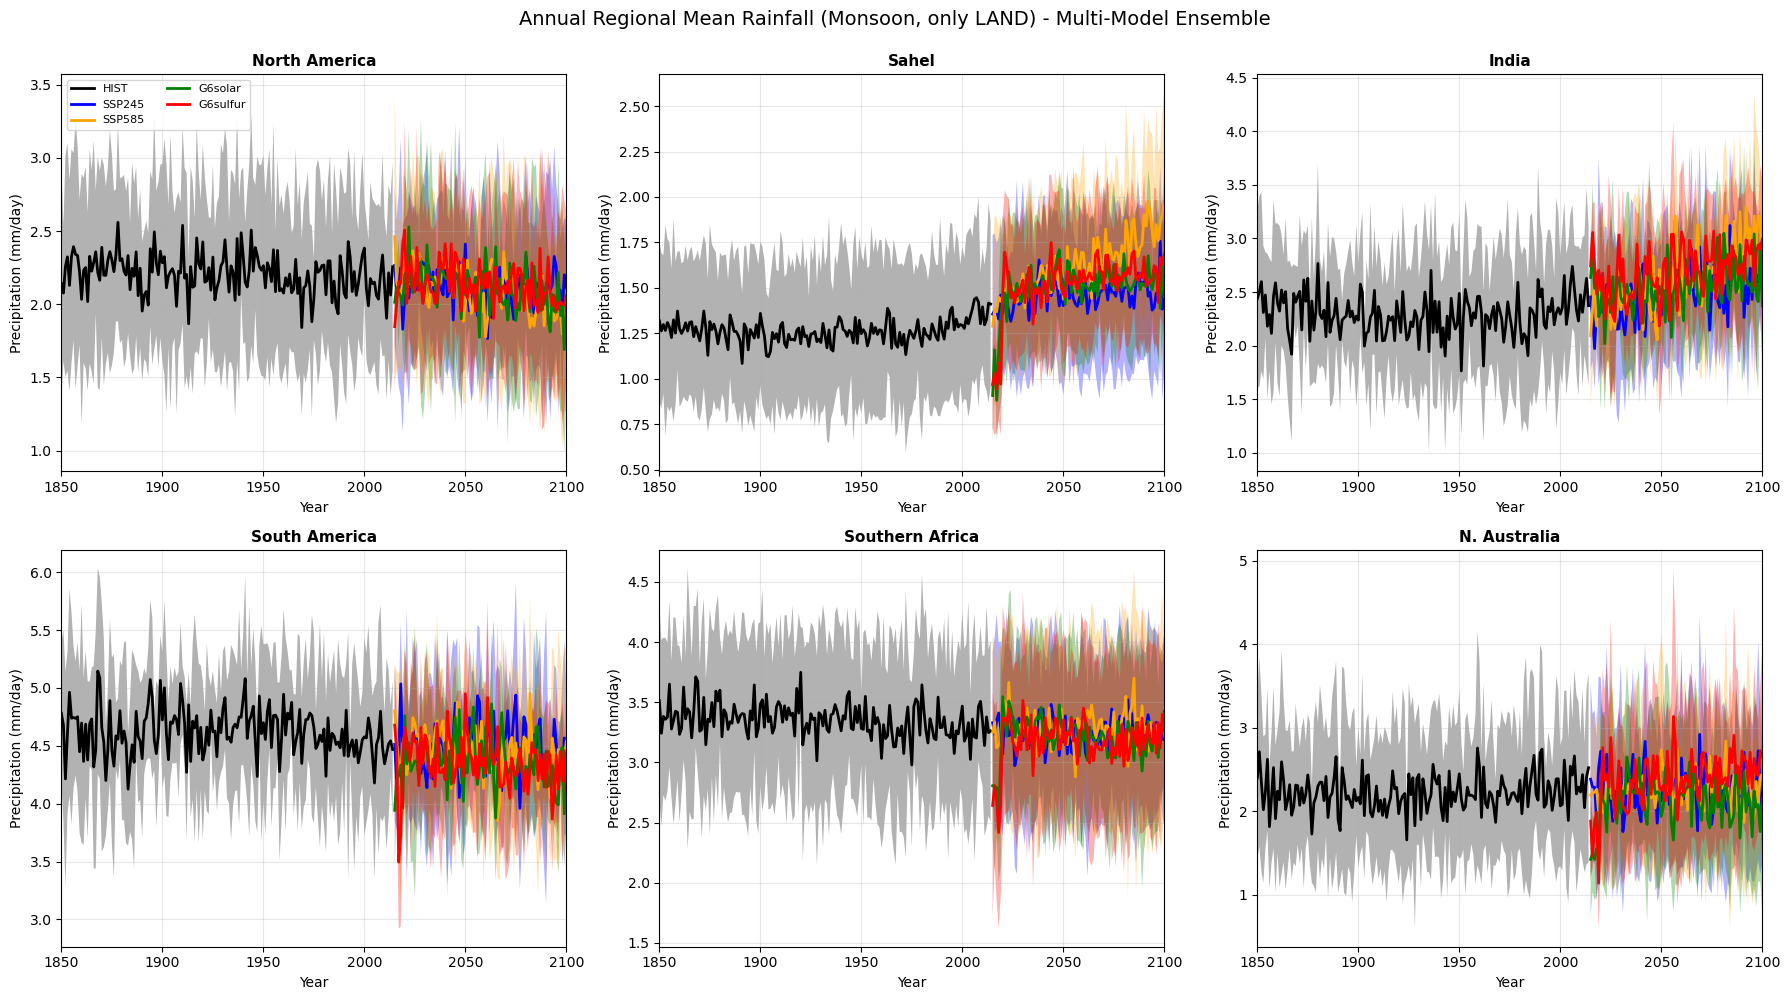

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

# Define domains
domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

# Create 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

all_ensemble_means = {}

# Loop over each domain
for domain_idx, (domain_name, domain_bounds) in enumerate(domains.items()):
    ax = axes[domain_idx]
    
    # Dictionary to store all model data by experiment for this domain
    data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}
    
    # --- Collect data from all models ---
    for model_name, model_meta in MODELS.items():
        var = {}
        var_by_year = {}
        
        # --- build paths + read data ---
        for exp, meta in EXPERIMENTS.items():
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                if meta["scenario"] == "G6sulfur":
                    ensemble = "r1i1p1f2"
                else:
                    ensemble = "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
            
            base = (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / varname
                / model_meta["grid"]
                / "latest"
            )
            print(f"{domain_name} - {model_name} - {exp}: {str(base)}")
            
            # Read data with model-specific handlers
            if model_name == "CESM2-WACCM":
                if meta["scenario"] == "G6sulfur":
                    ds = mf.open_files_CESM_G6sulfur(base)
                elif meta["scenario"] == "ssp585":
                    ds = mf.open_files_CESM_ssp585(base)
                else:
                    ds = mf.open_files(str(base))
            elif model_name == "IPSL-CM6A-LR":
                if meta["scenario"] == "ssp585":
                    ds = mf.open_files_IPSL_ssp585(base)
                else:
                    ds = mf.open_files(str(base))
            else:
                ds = mf.open_files(str(base))
            
            var[exp] = mf.read_var(ds, varname)
            
            # Select domain region
            lat_min, lat_max = domain_bounds["lat"]
            lon_min, lon_max = domain_bounds["lon"]
            var[exp] = var[exp].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
        
        # --- seasonal means ---
        seasons = {
            "ANN": (1, 12),
        }
        
        for exp, da in var.items():
            var_by_year[exp] = {}
            
            # Create land/ocean mask ONCE per experiment
            lat = da.lat.values
            lon = da.lon.values
            
            try:
                land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
                # Create 2D lon/lat mesh for masking
                lon_2d, lat_2d = np.meshgrid(lon, lat)
                mask_2d = land_110.mask(lon_2d, lat_2d)
                
                # Create land mask DataArray (True where land exists)
                land_mask_da = xr.DataArray(
                    ~np.isnan(mask_2d.values),
                    dims=["lat", "lon"],
                    coords={"lat": lat, "lon": lon}
                )
            except (ImportError, AttributeError) as e:
                import warnings
                warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
                land_mask_da = xr.DataArray(
                    np.ones((len(lat), len(lon)), dtype=bool),
                    dims=["lat", "lon"],
                    coords={"lat": lat, "lon": lon}
                )
            
            ocean_mask_da = ~land_mask_da
            
            # Apply mask to the full DataArray BEFORE seasonal processing
            da_land = da.where(land_mask_da)  # LAND
            # da_ocean = da.where(ocean_mask_da)  # OCEAN
            
            # Calculate seasonal means on the masked data
            for season, (m1, m2) in seasons.items():
                var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
        
        # --- Store mean time series for each experiment ---
        for exp in EXPERIMENTS.keys():
            ts = var_by_year[exp]["ANN"] * 86400
            data_by_experiment[exp].append(ts)
    
    # --- Define common year range ---
    common_years = np.arange(1850, 2101)
    
    # --- Plot ensemble mean and spread for this domain ---
    for exp, meta in EXPERIMENTS.items():
        all_models = data_by_experiment[exp]
        
        if len(all_models) == 0:
            continue
        
        # Align all models to common year grid
        aligned_data = []
        for ts in all_models:
            series = pd.Series(ts.values, index=ts.year.values)
            aligned = series.reindex(common_years)
            aligned_data.append(aligned.values)
        
        # Stack into 2D array (models x years)
        model_data = np.array(aligned_data)
        
        # Calculate ensemble mean and spread (ignoring NaNs)
        ensemble_mean = np.nanmean(model_data, axis=0)
        ensemble_std = np.nanstd(model_data, axis=0)

        #Saving ensemble_mean
        key = (domain_name, exp)
        all_ensemble_means[key] = {
            "years": common_years.copy(),
            "mean": ensemble_mean.copy(),
            "std": ensemble_std.copy(),  # optional
        }
        
        # Only plot where we have at least one model's data
        valid_mask = ~np.isnan(ensemble_mean)
        
        # Plot mean line
        line_color = meta.get("color", None)
        ax.plot(
            common_years[valid_mask],
            ensemble_mean[valid_mask],
            label=exp,
            color=line_color,
            linewidth=2,
        )
        
        # Plot shaded spread (±1 standard deviation)
        ax.fill_between(
            common_years[valid_mask],
            (ensemble_mean - ensemble_std)[valid_mask],
            (ensemble_mean + ensemble_std)[valid_mask],
            facecolor=line_color,
            alpha=0.3,
            edgecolor='none',
        )
    
    # Format individual subplot
    ax.set_ylabel("Precipitation (mm/day)", fontsize=10)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_title(f"{domain_name}", fontsize=11, fontweight='bold')
    ax.set_xlim(1850, 2100)
    ax.grid(True, alpha=0.3)
    
    # Add legend only to first subplot
    if domain_idx == 0:
        ax.legend(ncol=2, fontsize=8, loc="upper left")

# Overall title
plt.suptitle("Annual Regional Mean Rainfall (Monsoon, only LAND) - Multi-Model Ensemble", fontsize=14, y=0.995)
plt.tight_layout()

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_RegionalMeanRainfall_LAND-MONSOON_EnsembleMean_PI2PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Plotting smoothed ensemble_means

In [26]:
#Getting rid of 2015-2020 values for SSP245, SSP585, G6solar and G6sulfur

import copy
all_ensemble_means_smooth = copy.deepcopy(all_ensemble_means)

years_to_nan = np.arange(2014, 2021)
target_experiments = ["SSP245", "SSP585", "G6solar", "G6sulfur"]

for (domain_name, exp), data in all_ensemble_means.items():
    
    if exp not in target_experiments:
        continue
    
    years = data["years"]
    values = data["mean"]
    
    # Create mask for 2015–2020
    mask = np.isin(years, years_to_nan)
    
    # Replace with NaN
    values[mask] = np.nan
    
    # Save back (not strictly needed since it's mutable)
    all_ensemble_means_smooth[(domain_name, exp)]["mean"] = values

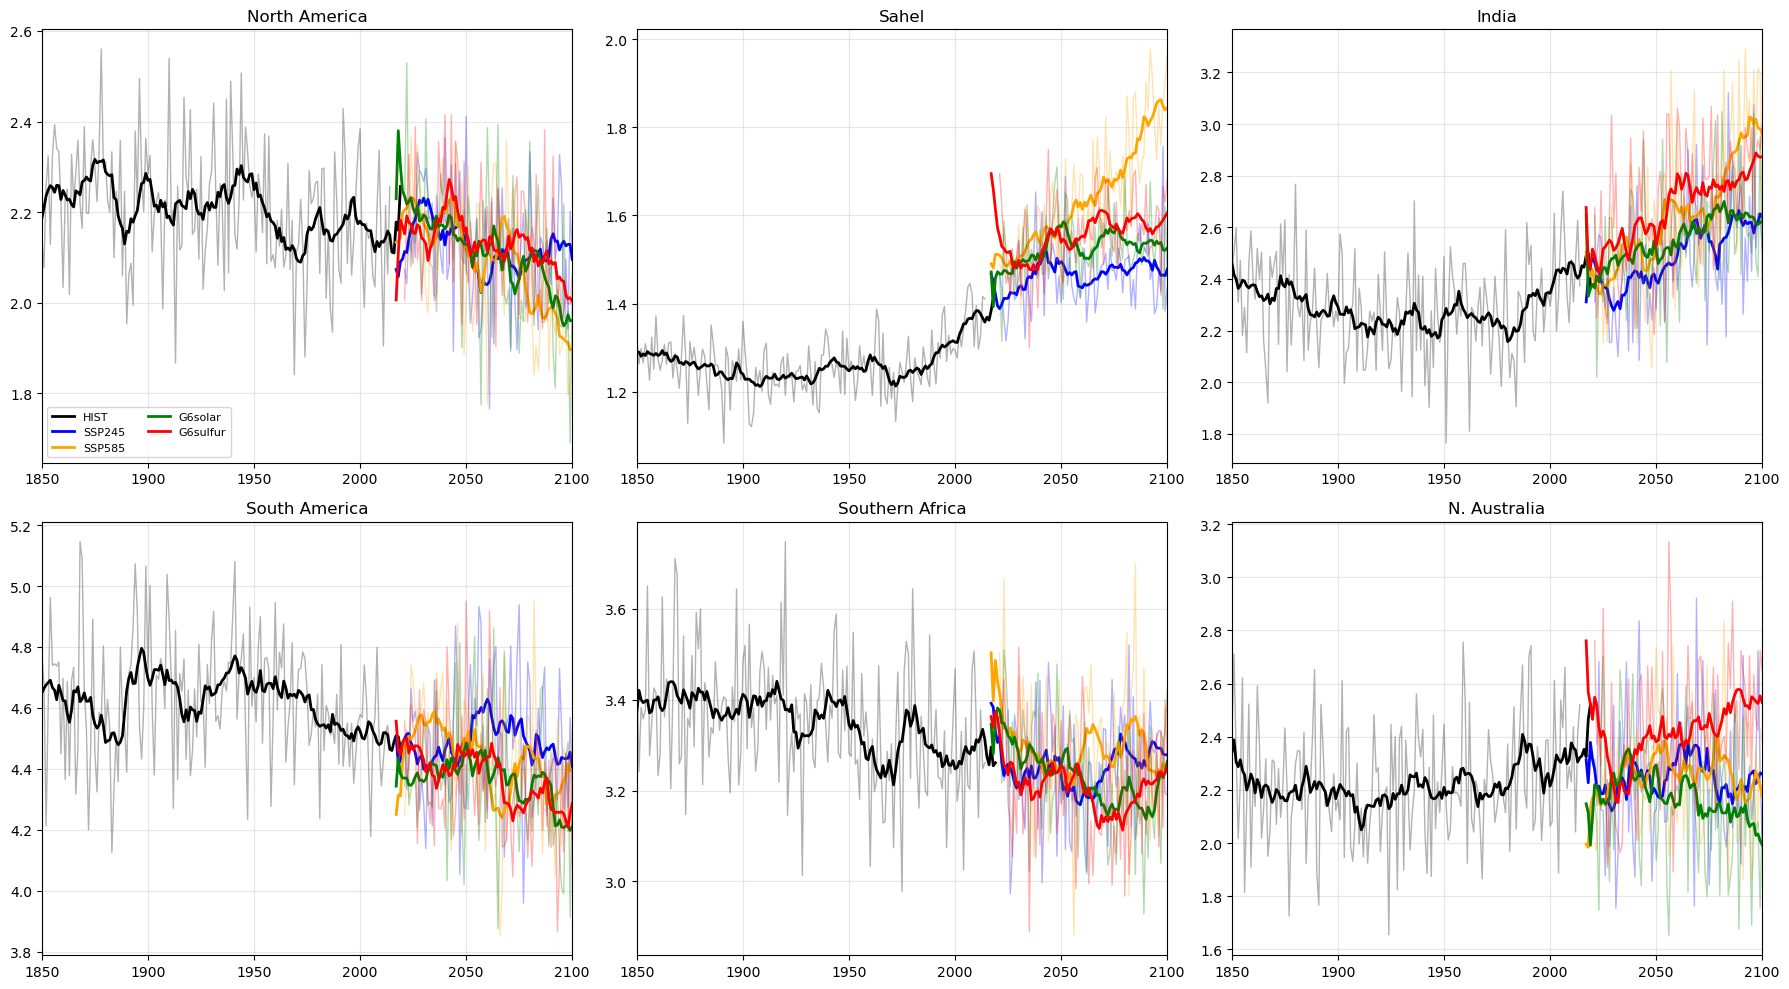

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

var=copy.deepcopy(all_ensemble_means_smooth)

window = 10  # 10-year smoothing

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

domains_list = list(domains.keys())

for i, domain_name in enumerate(domains_list):
    ax = axes[i]
    
    for exp, meta in EXPERIMENTS.items():
        key = (domain_name, exp)
        
        if key not in var:
            continue
        
        data = all_ensemble_means[key]
        years = data["years"]
        values = data["mean"]
        
        # Smooth
        smoothed = pd.Series(values).rolling(
            window=window, center=True, min_periods=1
        ).mean().values
        
        # Plot raw (faint)
        ax.plot(years, values, color=meta["color"], alpha=0.3, linewidth=1)
        
        # Plot smoothed (bold)
        ax.plot(years, smoothed, color=meta["color"], linewidth=2, label=exp)
    
    ax.set_title(domain_name)
    ax.set_xlim(1850, 2100)
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

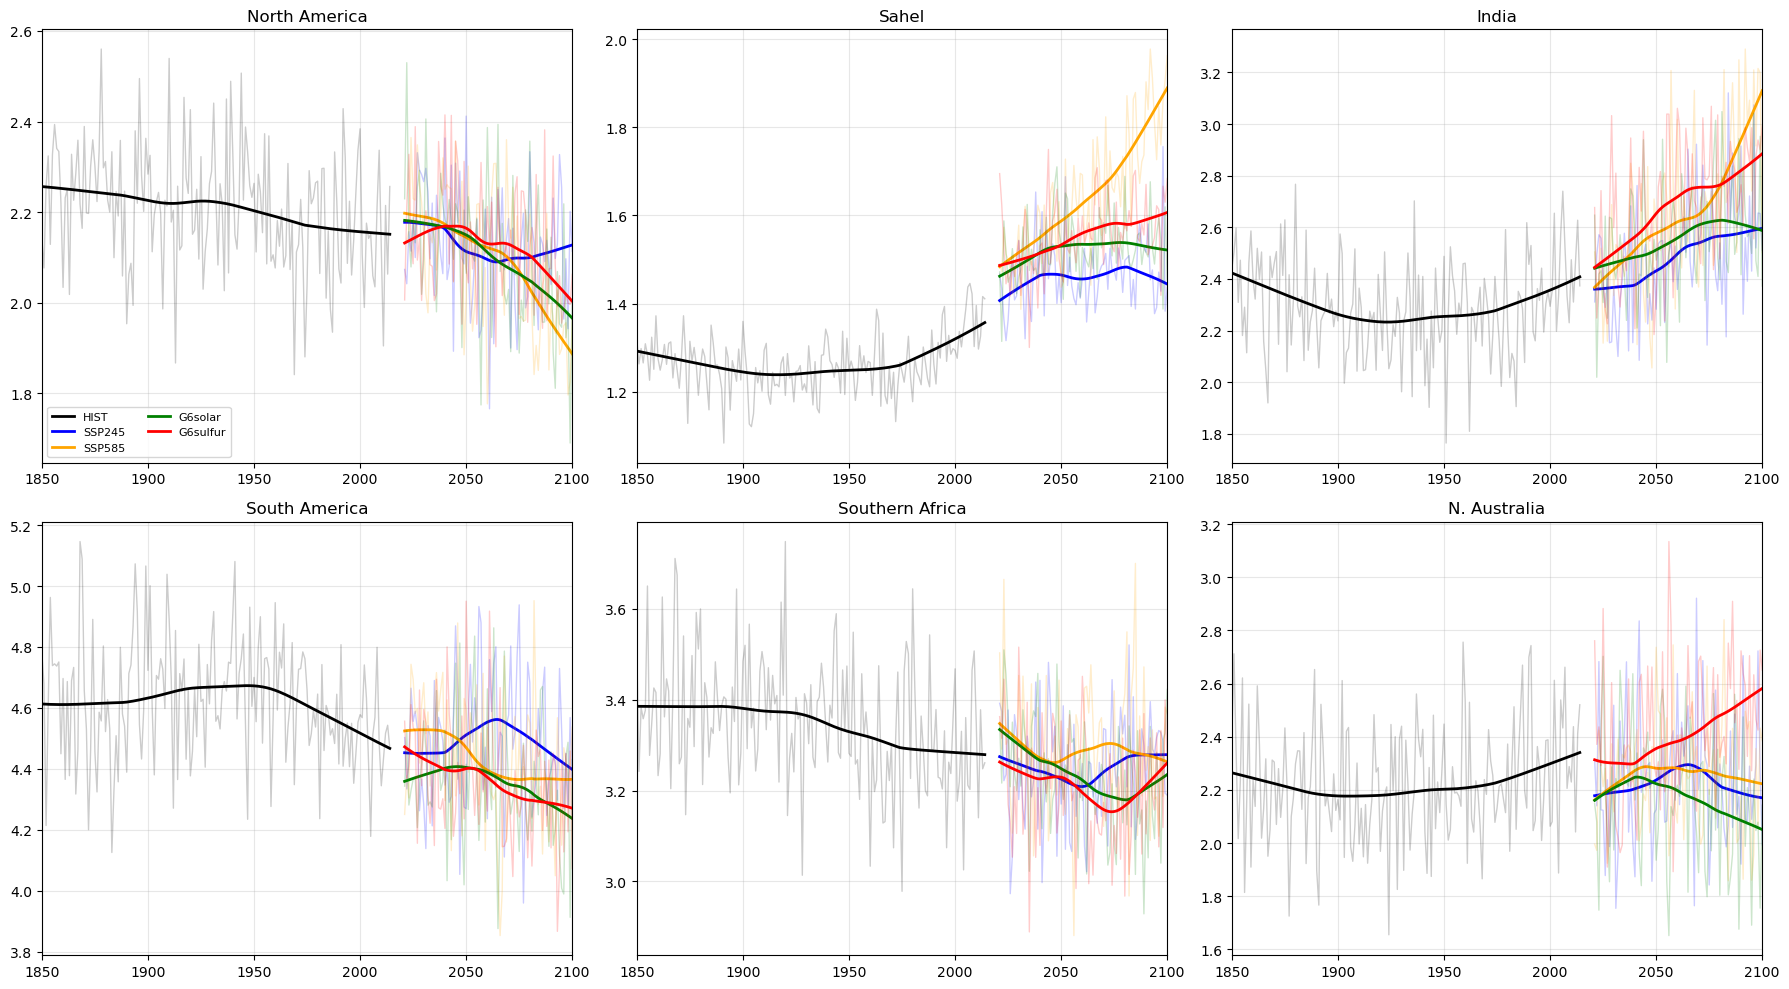

In [46]:
from statsmodels.nonparametric.smoothers_lowess import lowess

var=all_ensemble_means_smooth

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, domain_name in enumerate(domains.keys()):
    ax = axes[i]
    
    for exp, meta in EXPERIMENTS.items():
        key = (domain_name, exp)
        
        if key not in var:
            continue
        
        data = all_ensemble_means[key]
        years = data["years"]
        values = data["mean"]
        
        valid = ~np.isnan(values)
        
        # LOWESS smoothing
        lowess_result = lowess(values[valid], years[valid], frac=0.5)
        
        # Raw
        ax.plot(years, values, color=meta["color"], alpha=0.2, linewidth=1)
        
        # Smooth
        ax.plot(lowess_result[:, 0], lowess_result[:, 1],
                color=meta["color"], linewidth=2, label=exp)
    
    ax.set_title(domain_name)
    ax.set_xlim(1850, 2100)
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In LOWESS (Locally Weighted Scatterplot Smoothing), the frac parameter controls how much data is used to smooth each point.

- LOWESS fits a small regression around each x-value

- frac determines the size of that neighborhood

- smoothing window size (as a fraction of total data)

# Plotting combined series : 
## DID NOT WORK AS ENVISIONED : DO NOT USE THIS PLOT : MAYBE USED FOR DIFFERENT PURPOSE

For each domain, create combined time series:

HIST + SSP2-4.5

HIST + SSP5-8.5

HIST + G6solar

HIST + G6sulfur

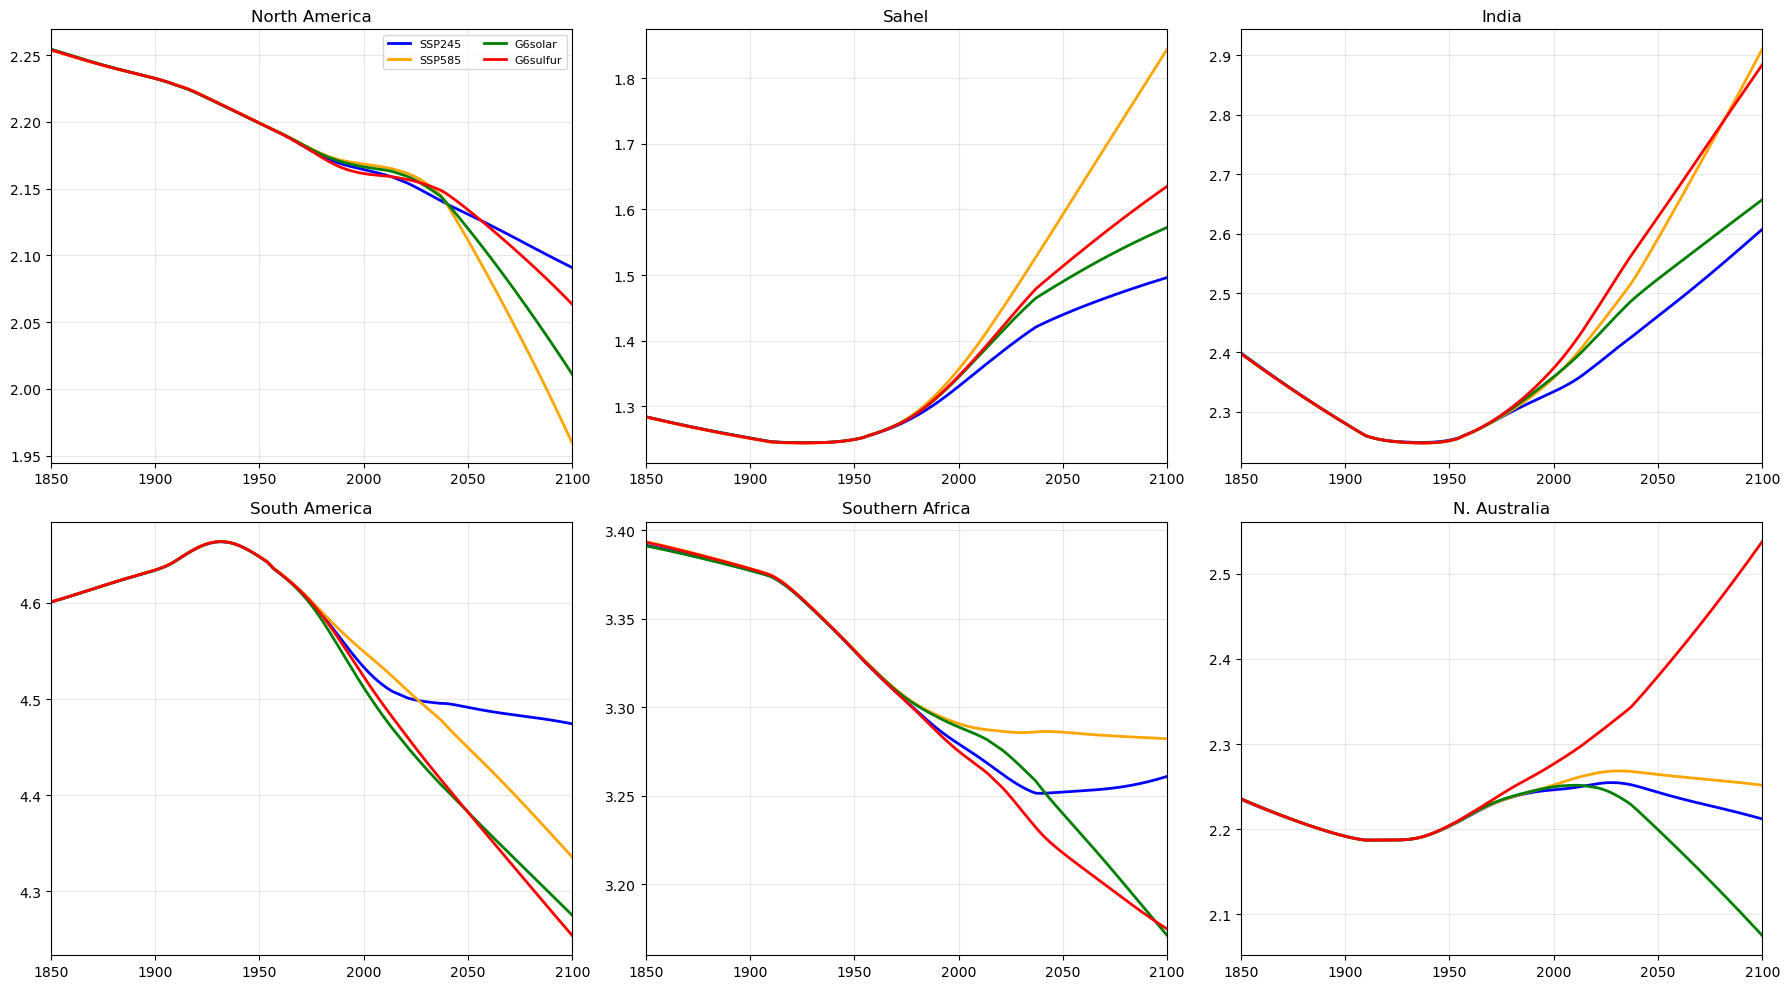

In [44]:
#Build combined time series

from statsmodels.nonparametric.smoothers_lowess import lowess

combined_series = {}

future_experiments = ["SSP245", "SSP585", "G6solar", "G6sulfur"]

for domain_name in domains.keys():
    
    # Get HIST
    hist_key = (domain_name, "HIST")
    if hist_key not in all_ensemble_means:
        continue
    
    hist_data = all_ensemble_means[hist_key]
    hist_years = hist_data["years"]
    hist_values = hist_data["mean"]
    
    for exp in future_experiments:
        fut_key = (domain_name, exp)
        
        if fut_key not in all_ensemble_means:
            continue
        
        fut_data = all_ensemble_means[fut_key]
        fut_years = fut_data["years"]
        fut_values = fut_data["mean"]
        
        # --- Combine ---
        combined_years = np.concatenate([hist_years, fut_years])
        combined_values = np.concatenate([hist_values, fut_values])
        
        # --- Sort (important!) ---
        sort_idx = np.argsort(combined_years)
        combined_years = combined_years[sort_idx]
        combined_values = combined_values[sort_idx]
        
        combined_series[(domain_name, exp)] = {
            "years": combined_years,
            "values": combined_values
        }


#Apply LOWESS smoothing
smoothed_series = {}

for key, data in combined_series.items():
    years = data["years"]
    values = data["values"]
    
    valid = ~np.isnan(values)
    
    lowess_result = lowess(
        values[valid],
        years[valid],
        frac=0.5  # adjust (0.05–0.2)
    )
    
    smoothed_series[key] = {
        "years": lowess_result[:, 0],
        "values": lowess_result[:, 1]
    }

#Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, domain_name in enumerate(domains.keys()):
    ax = axes[i]
    
    for exp, meta in EXPERIMENTS.items():
        if exp not in future_experiments:
            continue
        
        key = (domain_name, exp)
        if key not in smoothed_series:
            continue
        
        smooth = smoothed_series[key]
        
        ax.plot(
            smooth["years"],
            smooth["values"],
            color=meta["color"],
            linewidth=2,
            label=exp
        )
    
    ax.set_title(domain_name)
    ax.set_xlim(1850, 2100)
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

# BLOB-ARROW PLOT

In [48]:
# Javeline arrows

In [126]:
# Computing mean and slope

analysis_results = {}

periods = {
    "HIST": (1950, 2014),
    "SSP245": (2021, 2100),
    "SSP585": (2021, 2100),
    "G6solar": (2021, 2100),
    "G6sulfur": (2021, 2100),
}

for (domain_name, exp), data in all_ensemble_means.items():
    
    if exp not in periods:
        continue
    
    years = data["years"]
    values = data["mean"]
    
    start, end = periods[exp]
    mask = (years >= start) & (years <= end)
    
    x = years[mask]
    y = values[mask]
    
    valid = ~np.isnan(y)
    x = x[valid]
    y = y[valid]
    
    if len(x) < 2:
        continue
    
    mean_val = np.mean(y)
    slope, intercept = np.polyfit(x, y, 1)
    midpoint = 0.5 * (start + end)
    
    analysis_results[(domain_name, exp)] = {
        "mean": mean_val,
        "slope": slope,
        "midpoint": midpoint,
    }

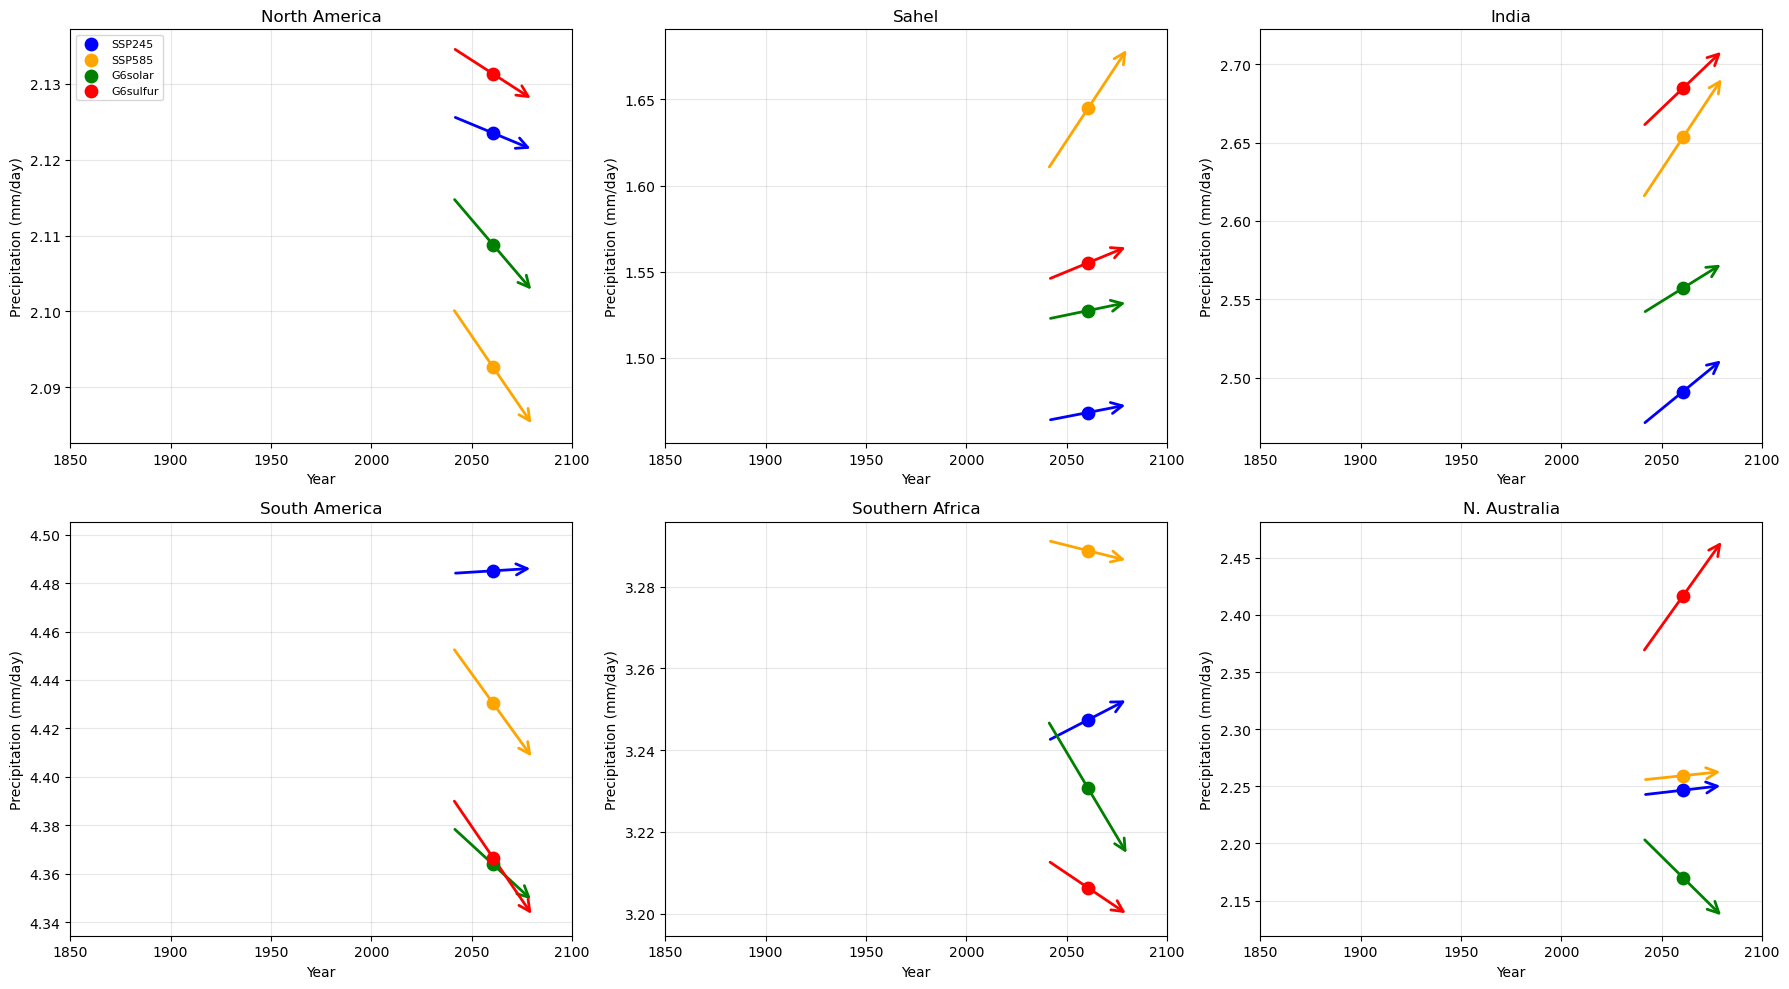

In [127]:
#The javeline plot

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
arrow_half_width = 20   # years

for i, domain_name in enumerate(domains.keys()):
    ax = axes[i]
    
    # Collect slopes for this domain
    domain_slopes = []
    domain_data = []
    
    for exp, meta in EXPERIMENTS.items():
        key = (domain_name, exp)
        if key not in analysis_results:
            continue
        domain_data.append((exp, meta, analysis_results[key]))
        domain_slopes.append(abs(analysis_results[key]["slope"]))
    
    if not domain_data:
        continue
    
    # Get y-range for this domain to scale arrows appropriately
    y_vals = [res["mean"] for _, _, res in domain_data]
    y_range = max(y_vals) - min(y_vals)
    
    # Make arrows 20% of the y-range at most
    max_arrow_height = 0.2 * y_range if y_range > 0 else 0.05
    max_slope = max(domain_slopes) if domain_slopes else 1
    
    for exp, meta, res in domain_data:
        x0 = res["midpoint"]
        y0 = res["mean"]
        slope = res["slope"]
        color = meta["color"]
        
        # Blob
        ax.scatter(x0, y0, color=color, s=80, zorder=3, label=exp)
        
        # Arrow scaled to data
        dx = arrow_half_width
        
        # Scale dy: normalize by max slope, then scale to visual range
        dy_normalized = (slope / max_slope) if max_slope != 0 else 0
        dy_actual = dy_normalized * max_arrow_height
        
        x_start = x0 - dx
        y_start = y0 - dy_actual
        
        x_end = x0 + dx
        y_end = y0 + dy_actual
        
        # Use FancyArrowPatch instead of annotate
        arrow = FancyArrowPatch(
            (x_start, y_start),
            (x_end, y_end),
            arrowstyle='->',
            color=color,
            lw=2,
            mutation_scale=20,
            zorder=2
        )
        ax.add_patch(arrow)
    
    ax.set_title(domain_name)
    ax.set_xlim(1850, 2100)
    ax.set_ylabel("Precipitation (mm/day)")
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

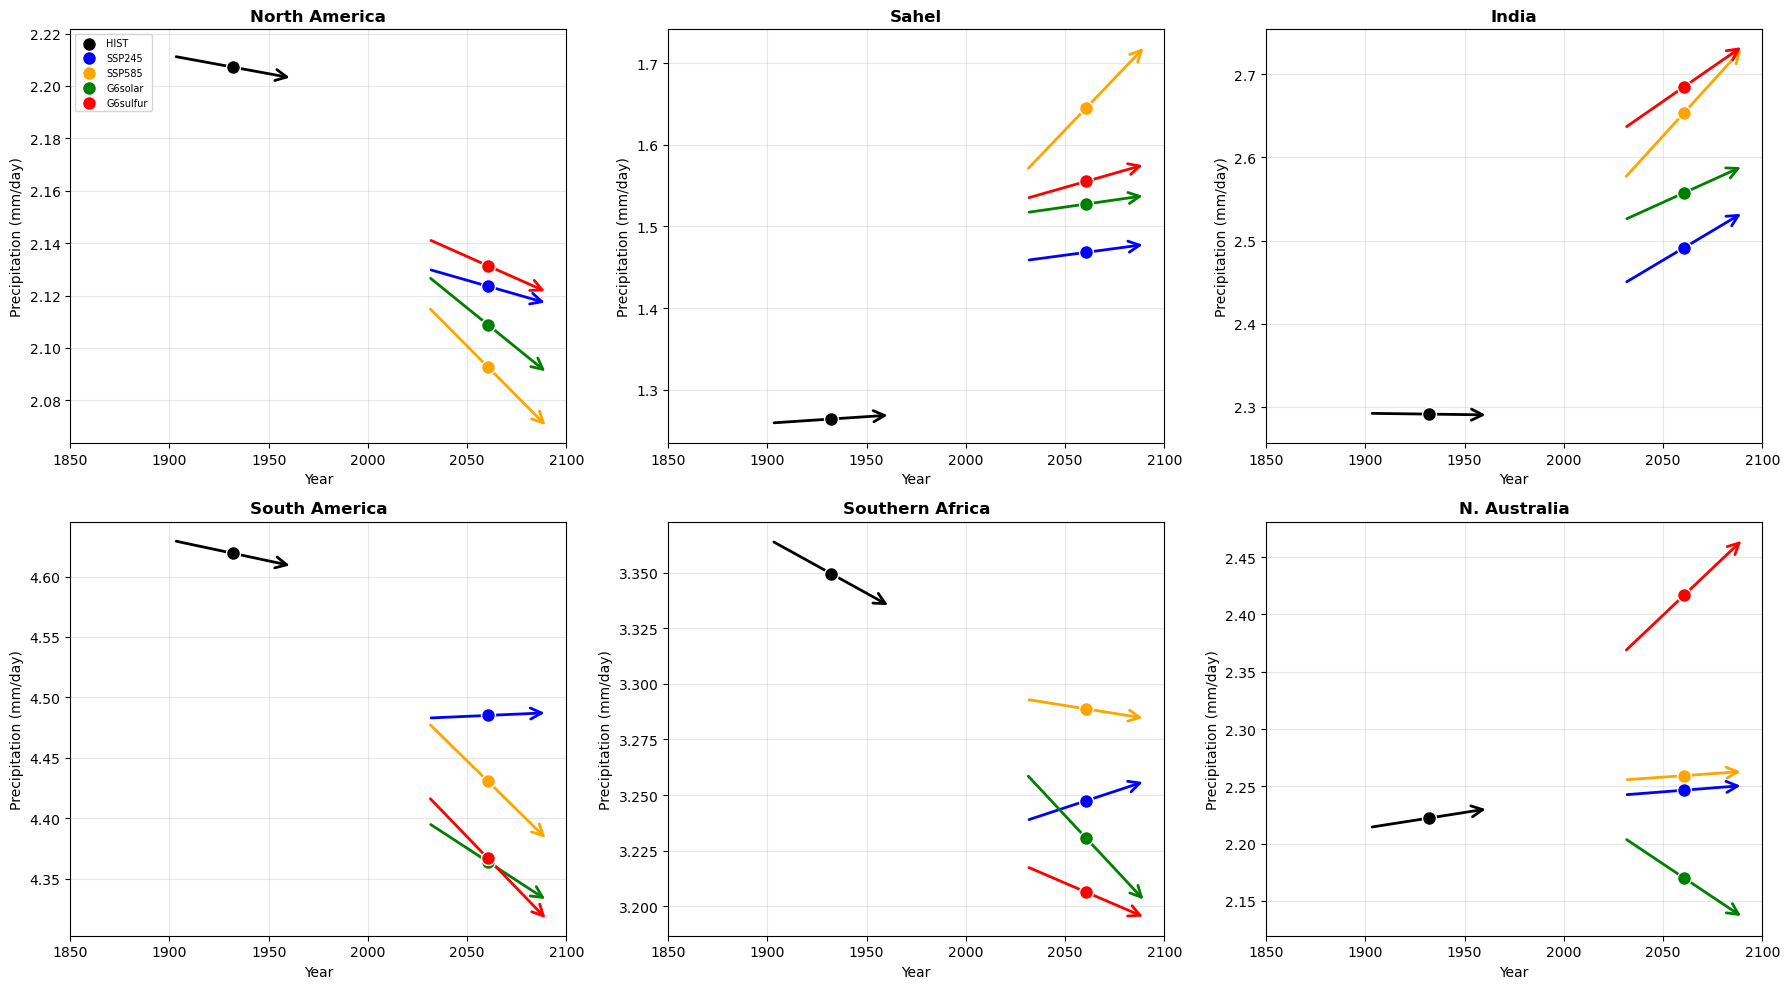

In [121]:
#The javeline plot - same as above ... maybe a bit better looking

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
arrow_half_width = 30   # years

for i, domain_name in enumerate(domains.keys()):
    ax = axes[i]
    
    domain_slopes = []
    domain_data = []
    
    for exp, meta in EXPERIMENTS.items():
        key = (domain_name, exp)
        if key not in analysis_results:
            continue
        domain_data.append((exp, meta, analysis_results[key]))
        domain_slopes.append(abs(analysis_results[key]["slope"]))
    
    if not domain_data:
        continue
    
    y_vals = [res["mean"] for _, _, res in domain_data]
    y_range = max(y_vals) - min(y_vals)
    max_arrow_height = 0.2 * y_range if y_range > 0 else 0.05
    max_slope = max(domain_slopes) if domain_slopes else 1
    
    # Sort by x-position (midpoint) to handle overlaps
    domain_data_sorted = sorted(domain_data, key=lambda x: x[2]["midpoint"])
    
    for exp, meta, res in domain_data_sorted:
        x0 = res["midpoint"]
        y0 = res["mean"]
        slope = res["slope"]
        color = meta["color"]
        
        # Blob with edge for visibility
        ax.scatter(x0, y0, color=color, s=100, zorder=4, 
                   edgecolors='white', linewidths=1, label=exp)
        
        dx = arrow_half_width
        dy_normalized = (slope / max_slope) if max_slope != 0 else 0
        dy_actual = dy_normalized * max_arrow_height
        
        x_start = x0 - dx
        y_start = y0 - dy_actual
        x_end = x0 + dx
        y_end = y0 + dy_actual
        
        # Use FancyArrowPatch instead of annotate
        arrow = FancyArrowPatch(
            (x_start, y_start),
            (x_end, y_end),
            arrowstyle='->',
            color=color,
            lw=2,
            mutation_scale=20,
            zorder=2
        )
        ax.add_patch(arrow)
    
    ax.set_title(domain_name, fontsize=12, fontweight='bold')
    ax.set_xlim(1850, 2100)
    ax.set_ylabel("Precipitation (mm/day)")
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

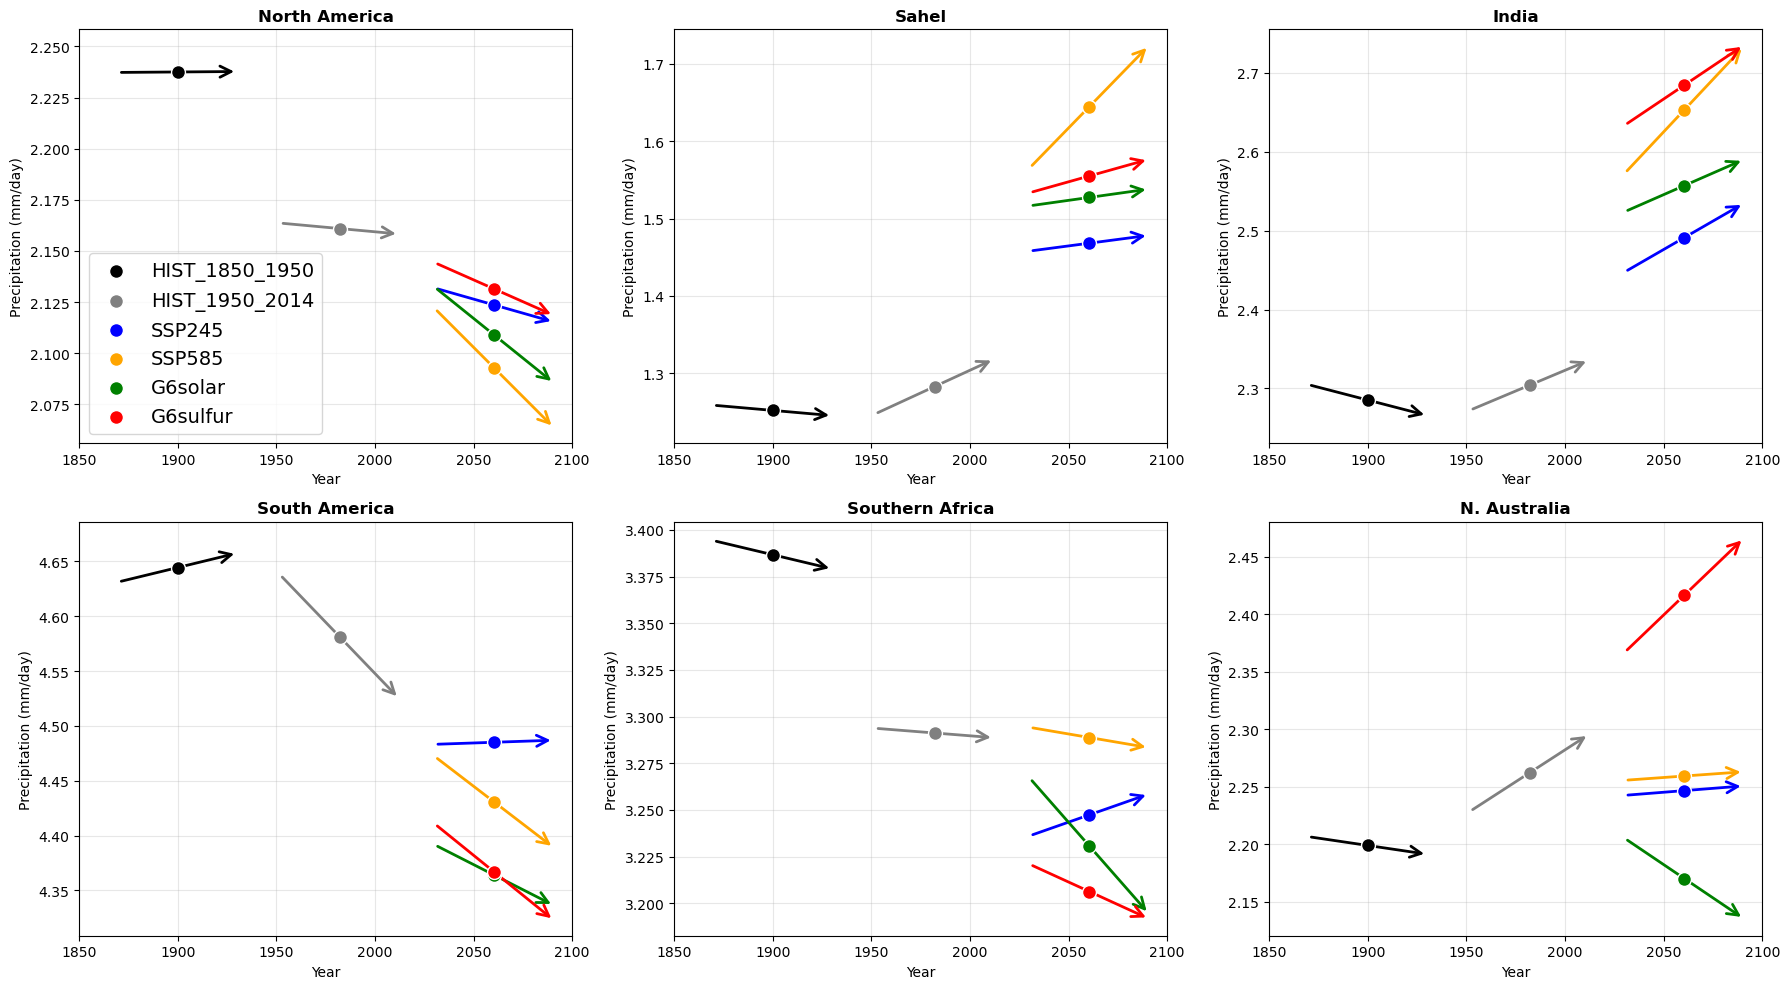

In [144]:
# Computing mean and slope
analysis_results = {}
periods = {
    "HIST_1850_1950": (1850, 1950),      # Full historical period
    "HIST_1950_2014": (1950, 2014),            # Post-1950 historical period
    "SSP245": (2021, 2100),
    "SSP585": (2021, 2100),
    "G6solar": (2021, 2100),
    "G6sulfur": (2021, 2100),
}

# Map experiment names to their period keys
exp_to_period = {
    "HIST": "HIST_1950_2014",           # Use 1950-2014 by default
    "SSP245": "SSP245",
    "SSP585": "SSP585",
    "G6solar": "G6solar",
    "G6sulfur": "G6sulfur",
}

for (domain_name, exp), data in all_ensemble_means.items():
    
    if exp not in exp_to_period:
        continue
    
    years = data["years"]
    values = data["mean"]
    
    # For HIST, compute both periods
    periods_to_compute = []
    if exp == "HIST":
        periods_to_compute = [
            ("HIST_1950_2014", periods["HIST_1950_2014"]),           # 1950-2014
            ("HIST_1850_1950", periods["HIST_1850_1950"])  # 1850-2014
        ]
    else:
        periods_to_compute = [(exp, periods[exp])]
    
    for exp_label, (start, end) in periods_to_compute:
        mask = (years >= start) & (years <= end)
        
        x = years[mask]
        y = values[mask]
        
        valid = ~np.isnan(y)
        x = x[valid]
        y = y[valid]
        
        if len(x) < 2:
            continue
        
        mean_val = np.mean(y)
        slope, intercept = np.polyfit(x, y, 1)
        midpoint = 0.5 * (start + end)
        
        analysis_results[(domain_name, exp_label)] = {
            "mean": mean_val,
            "slope": slope,
            "midpoint": midpoint,
        }


#The javeline plot - same as above ... maybe a bit better looking

EXPERIMENTS_new = {
    "HIST_1850_1950": {"color": "black", "linestyle": "-", "alpha": 0.5},  # 1850-2014
    "HIST_1950_2014": {"color": "gray", "linestyle": "-"},                   # 1950-2014
    "SSP245": {"color": "blue", "linestyle": "--"},
    "SSP585": {"color": "orange", "linestyle": "--"},
    "G6solar": {"color": "green", "linestyle": ":"},
    "G6sulfur": {"color": "red", "linestyle": ":"},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
arrow_half_width = 30   # years

for i, domain_name in enumerate(domains.keys()):
    ax = axes[i]
    
    domain_slopes = []
    domain_data = []
    
    for exp, meta in EXPERIMENTS_new.items():
        key = (domain_name, exp)
        if key not in analysis_results:
            continue
        domain_data.append((exp, meta, analysis_results[key]))
        domain_slopes.append(abs(analysis_results[key]["slope"]))
    
    if not domain_data:
        continue
    
    y_vals = [res["mean"] for _, _, res in domain_data]
    y_range = max(y_vals) - min(y_vals)
    max_arrow_height = 0.2 * y_range if y_range > 0 else 0.05
    max_slope = max(domain_slopes) if domain_slopes else 1
    
    # Sort by x-position (midpoint) to handle overlaps
    domain_data_sorted = sorted(domain_data, key=lambda x: x[2]["midpoint"])
    
    for exp, meta, res in domain_data_sorted:
        x0 = res["midpoint"]
        y0 = res["mean"]
        slope = res["slope"]
        color = meta["color"]
        
        # Blob with edge for visibility
        ax.scatter(x0, y0, color=color, s=100, zorder=4, 
                   edgecolors='white', linewidths=1, label=exp)
        
        dx = arrow_half_width
        dy_normalized = (slope / max_slope) if max_slope != 0 else 0
        dy_actual = dy_normalized * max_arrow_height
        
        x_start = x0 - dx
        y_start = y0 - dy_actual
        x_end = x0 + dx
        y_end = y0 + dy_actual
        
        # Use FancyArrowPatch instead of annotate
        arrow = FancyArrowPatch(
            (x_start, y_start),
            (x_end, y_end),
            arrowstyle='->',
            color=color,
            lw=2,
            mutation_scale=20,
            zorder=2
        )
        ax.add_patch(arrow)
    
    ax.set_title(domain_name, fontsize=12, fontweight='bold')
    ax.set_xlim(1850, 2100)
    ax.set_ylabel("Precipitation (mm/day)")
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=14, loc='lower left')

plt.tight_layout()
plt.show()

# Done with blob arrow

North America - UKESM1-0-LL - HIST: /badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - SSP245: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - SSP585: /badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - G6solar: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/pr/gn/latest
North America - UKESM1-0-LL - G6sulfur: /badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
North America - CNRM-ESM2-1 - HIST: /badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
North America - CNRM-ESM2-1 - SSP245: /badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/pr/gr/latest
North America - CNRM-ESM2-1 - SSP585: /badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp585/r1i1p1f2/Amon/pr/gr/lates

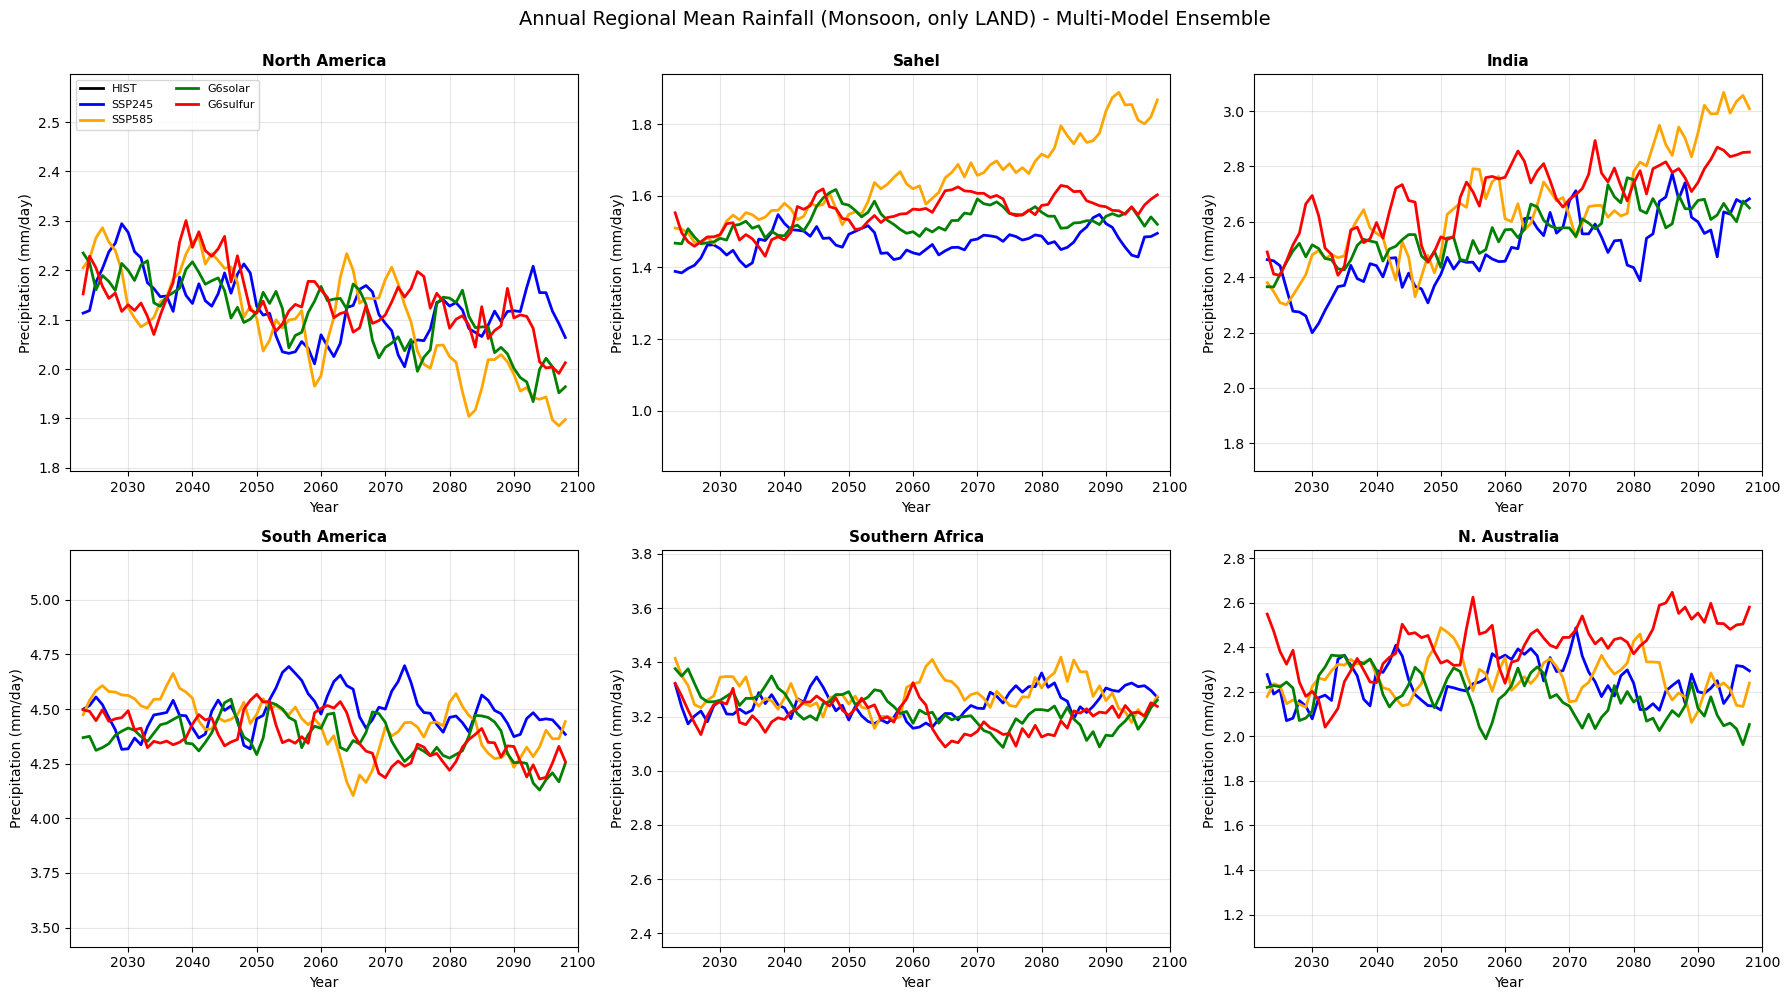

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import regionmask
import xarray as xr

# Define domains
domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

# Create 2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop over each domain
for domain_idx, (domain_name, domain_bounds) in enumerate(domains.items()):
    ax = axes[domain_idx]
    
    # Dictionary to store all model data by experiment for this domain
    data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}
    
    # --- Collect data from all models ---
    for model_name, model_meta in MODELS.items():
        var = {}
        var_by_year = {}
        
        # --- build paths + read data ---
        for exp, meta in EXPERIMENTS.items():
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                if meta["scenario"] == "G6sulfur":
                    ensemble = "r1i1p1f2"
                else:
                    ensemble = "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
            
            base = (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / varname
                / model_meta["grid"]
                / "latest"
            )
            print(f"{domain_name} - {model_name} - {exp}: {str(base)}")
            
            # Read data with model-specific handlers
            if model_name == "CESM2-WACCM":
                if meta["scenario"] == "G6sulfur":
                    ds = mf.open_files_CESM_G6sulfur(base)
                elif meta["scenario"] == "ssp585":
                    ds = mf.open_files_CESM_ssp585(base)
                else:
                    ds = mf.open_files(str(base))
            elif model_name == "IPSL-CM6A-LR":
                if meta["scenario"] == "ssp585":
                    ds = mf.open_files_IPSL_ssp585(base)
                else:
                    ds = mf.open_files(str(base))
            else:
                ds = mf.open_files(str(base))
            
            var[exp] = mf.read_var(ds, varname)
            
            # Select domain region
            lat_min, lat_max = domain_bounds["lat"]
            lon_min, lon_max = domain_bounds["lon"]
            var[exp] = var[exp].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
        
        # --- seasonal means ---
        seasons = {
            "ANN": (1, 12),
        }
        
        for exp, da in var.items():
            var_by_year[exp] = {}
            
            # Create land/ocean mask ONCE per experiment
            lat = da.lat.values
            lon = da.lon.values
            
            try:
                land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
                # Create 2D lon/lat mesh for masking
                lon_2d, lat_2d = np.meshgrid(lon, lat)
                mask_2d = land_110.mask(lon_2d, lat_2d)
                
                # Create land mask DataArray (True where land exists)
                land_mask_da = xr.DataArray(
                    ~np.isnan(mask_2d.values),
                    dims=["lat", "lon"],
                    coords={"lat": lat, "lon": lon}
                )
            except (ImportError, AttributeError) as e:
                import warnings
                warnings.warn(f"regionmask error: {e} — using all-grid proxy.")
                land_mask_da = xr.DataArray(
                    np.ones((len(lat), len(lon)), dtype=bool),
                    dims=["lat", "lon"],
                    coords={"lat": lat, "lon": lon}
                )
            
            ocean_mask_da = ~land_mask_da
            
            # Apply mask to the full DataArray BEFORE seasonal processing
            da_land = da.where(land_mask_da)  # LAND
            # da_ocean = da.where(ocean_mask_da)  # OCEAN
            
            # Calculate seasonal means on the masked data
            for season, (m1, m2) in seasons.items():
                var_by_year[exp][season] = mf.seasonal_mean_by_year(da_land, m1, m2).mean(dim=("lat", "lon"))
        
        # --- Store mean time series for each experiment ---
        for exp in EXPERIMENTS.keys():
            ts = var_by_year[exp]["ANN"] * 86400
            data_by_experiment[exp].append(ts)
    
    # --- Define common year range ---
    common_years = np.arange(1850, 2101)
    
    # --- Plot ensemble mean and spread for this domain ---
    for exp, meta in EXPERIMENTS.items():
        all_models = data_by_experiment[exp]
        
        if len(all_models) == 0:
            continue
        
        # Align all models to common year grid
        aligned_data = []
        for ts in all_models:
            series = pd.Series(ts.values, index=ts.year.values)
            aligned = series.reindex(common_years)
            aligned_data.append(aligned.values)
        
        # Stack into 2D array (models x years)
        model_data = np.array(aligned_data)
        
        # Calculate ensemble mean and spread (ignoring NaNs)
        ensemble_mean = np.nanmean(model_data, axis=0)
        ensemble_std = np.nanstd(model_data, axis=0)
        
        # Only plot where we have at least one model's data
        valid_mask = ~np.isnan(ensemble_mean)
        
        # Plot mean line
        line_color = meta.get("color", None)
        # ax.plot(
        #     common_years[valid_mask],
        #     ensemble_mean[valid_mask],
        #     label=exp,
        #     color=line_color,
        #     linewidth=2,
        # )
        
        # # Plot shaded spread (±1 standard deviation)
        # ax.fill_between(
        #     common_years[valid_mask],
        #     (ensemble_mean - ensemble_std)[valid_mask],
        #     (ensemble_mean + ensemble_std)[valid_mask],
        #     facecolor=line_color,
        #     alpha=0.3,
        #     edgecolor='none',
        # )

        # Smooth only the data after 2020
        smooth_window = 5  # Adjust window size as needed
        years_plot = common_years[valid_mask]
        values_plot = ensemble_mean[valid_mask]
        
        # Create mask for years > 2020
        post_2020_mask = years_plot > 2020
        smoothed_values = values_plot.copy()
        smoothed_values[post_2020_mask] = pd.Series(values_plot[post_2020_mask]).rolling(window=smooth_window, center=True).mean().values
        
        ax.plot(
            years_plot,
            smoothed_values,
            label=exp,
            color=line_color,
            linewidth=2,
        )
    
    # Format individual subplot
    ax.set_ylabel("Precipitation (mm/day)", fontsize=10)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_title(f"{domain_name}", fontsize=11, fontweight='bold')
    ax.set_xlim(2021, 2100)
    ax.grid(True, alpha=0.3)
    
    # Add legend only to first subplot
    if domain_idx == 0:
        ax.legend(ncol=2, fontsize=8, loc="upper left")

# Overall title
plt.suptitle("Annual Regional Mean Rainfall (Monsoon, only LAND) - Multi-Model Ensemble", fontsize=14, y=0.995)
plt.tight_layout()

# Save
fig_directory = "/home/users/bidyut/UoE/20260112_Basic_Analysis"
figname = "Figure_RegionalMeanRainfall_LAND-MONSOON_EnsembleMean_19502PD2SAI"
plt.savefig(f"{fig_directory}/{figname}.pdf", format="pdf", bbox_inches='tight')
plt.show()